In [1]:
import numpy as np
import pandas as pd
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
from rdkit.Chem import Draw
from matplotlib.ticker import MaxNLocator
from scipy.stats import pearsonr

# Fig 4

## Panels a-f

In [2]:
combinations = [
    ["BXPC3", "CAPAN"],
    ["BXPC3", "HEK"],
    ["CAPAN", "HEK"],
    ["CAPAN", "CFPAC"],
    ["HEK", "BXPC3"],
    ["HEK", "CAPAN"],
    ["HEK", "CFPAC"],
]

clls = ["BXPC3", "CAPAN", "HEK", "CFPAC"]

thresholds = {"CAPAN": 30.9, "BXPC3": 21.95, "CFPAC": 35.05, "HEK": 48.15}

In [4]:
results = pd.read_excel(
    "../../drug screening data/Validation of generated molecules vs prediction only approach.xlsx", sheet_name = 'Validation of NCEs'
)
results.head()

,SMILES,Supplier,Supplier Ref,Conc,% Inh BXPC3 rep1,% Inh BXPC3 rep2,% Inh BXPC3 rep3,% Inh CAPAN2 rep1,% Inh CAPAN2 rep2,% Inh CAPAN2 rep3,% Inh CFPAC1 rep1,% Inh CFPAC1 rep2,% Inh CFPAC1 rep3,% Inh HEK293 rep1,% Inh HEK293 rep2,% Inh HEK293 rep3
0,C(=C1C(=O)NC2C=CC=CC=21)C1C2C=CC=CC=2NC=1C1=CC...,Maybridge,HTS05068SC,1 uM,-2.2013,4.9652,7.4744,-5.4366,-3.97960,-1.56220,0.97032,-7.1862,8.7617,21.5260,19.5270,21.0300
1,C(=C1C(=O)NC2C=CC=CC=21)C1C2C=CC=CC=2NC=1C1=CC...,Maybridge,HTS05068SC,10 uM,38.8470,26.4810,34.3020,12.9220,10.87800,-0.23526,27.18500,29.5070,20.9840,67.2060,61.1630,60.7760
2,C1(=O)C2=CC=CC=C2SC2C=CC(=CC=2N1)C(NCCC1C=CC(=...,Mcule,MCULE-1477843803,1 uM,-4.3469,-1.3673,-14.6870,-6.1786,-0.21616,-2.90370,-4.56420,-3.6454,-12.4590,6.5656,6.1441,3.9810
3,C1(=O)C2=CC=CC=C2SC2C=CC(=CC=2N1)C(NCCC1C=CC(=...,Mcule,MCULE-1477843803,10 uM,23.9910,18.6080,23.3690,9.5590,6.50400,14.46100,20.70500,9.1902,19.4930,67.5150,63.0500,61.4010
4,C1(C(=O)NC2=CC=C(C=C2)C)=C(N)C2=C(N=C3C(CCCC3)...,Mcule,MCULE-6325569038,1 uM,-11.0200,3.1101,-6.7132,-10.9430,-4.36140,-9.13320,2.20460,-3.4436,-2.4091,-7.3113,4.9472,-9.5225


In [5]:
r10uM = results[results["Conc"] == "10 uM"]

In [6]:
r1uM = results[results["Conc"] == "1 uM"]

In [7]:
# Aggregate replicates
for cll in clls:
    replicates = r10uM.filter(like=cll)
    mean2closest = []
    for i in range(len(replicates)):
        aux = replicates.iloc[i, :]
        a = abs(aux[0] - aux[1])
        b = abs(aux[0] - aux[2])
        c = abs(aux[1] - aux[2])
        min_index = np.where([a, b, c] == min([a, b, c]))[0]
        if min_index == 0:
            mean2closest.append(np.mean([aux[0], aux[1]]))
        elif min_index == 1:
            mean2closest.append(np.mean([aux[0], aux[2]]))
        elif min_index == 2:
            mean2closest.append(np.mean([aux[1], aux[2]]))

    r10uM[cll + "_mean"] = replicates.mean(axis=1)
    r10uM[cll + "_mean2closest"] = mean2closest

/tmp/ipykernel_47907/3646429094.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = abs(aux[0] - aux[1])
/tmp/ipykernel_47907/3646429094.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b = abs(aux[0] - aux[2])
/tmp/ipykernel_47907/3646429094.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c = abs(aux[1] - aux[2])
/tmp/ipykernel_47907/3646429094.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprec

In [8]:
# Aggregate replicates
for cll in clls:
    replicates = r1uM.filter(like=cll)
    mean2closest = []
    for i in range(len(replicates)):
        aux = replicates.iloc[i, :]
        a = abs(aux[0] - aux[1])
        b = abs(aux[0] - aux[2])
        c = abs(aux[1] - aux[2])
        min_index = np.where([a, b, c] == min([a, b, c]))[0]
        if min_index == 0:
            mean2closest.append(np.mean([aux[0], aux[1]]))
        elif min_index == 1:
            mean2closest.append(np.mean([aux[0], aux[2]]))
        elif min_index == 2:
            mean2closest.append(np.mean([aux[1], aux[2]]))

    r1uM[cll + "_mean"] = replicates.mean(axis=1)
    r1uM[cll + "_mean2closest"] = mean2closest

/tmp/ipykernel_47907/1274348408.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = abs(aux[0] - aux[1])
/tmp/ipykernel_47907/1274348408.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b = abs(aux[0] - aux[2])
/tmp/ipykernel_47907/1274348408.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c = abs(aux[1] - aux[2])
/tmp/ipykernel_47907/1274348408.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprec

## Binarize data

In [10]:
# Binarize the pivot_df DataFrame based on the thresholds
r10uM_binary = r10uM.copy()  # Make a copy to avoid modifying the original DataFrame
for cll in clls:
    r10uM_binary[cll + "_mean2closest"] = r10uM_binary[cll + "_mean2closest"].apply(
        lambda x: 1 if x >= thresholds[cll] else 0
    )
r10uM_binary = r10uM_binary.filter(like="mean2closest")


In [12]:
# Binarize the pivot_df DataFrame based on the thresholds
r1uM_binary = r1uM.copy()  # Make a copy to avoid modifying the original DataFrame
for cll in clls:
    r1uM_binary[cll + "_mean2closest"] = r1uM_binary[cll + "_mean2closest"].apply(
        lambda x: 1 if x >= thresholds[cll] else 0
    )
r1uM_binary = r1uM_binary.filter(like="mean2closest")


In [ ]:
r1uM.filter(regex="_mean$")

Plate Name,BXPC3_mean,CAPAN_mean,HEK_mean,CFPAC_mean
Sample,,,,
0234_0037,-3.726800,1.440013,1.473467,1.870417
0310_0156,-1.774877,-3.263100,20.308000,-1.681450
1488_2470,-1.042303,1.951100,-13.983000,-2.158113
2082_0205,-3.963143,-0.498350,7.867120,-4.413633
4204_0050,14.320800,11.001367,12.858100,8.198967
...,...,...,...,...
Y021_4491,-4.582767,-9.169000,-8.764733,-4.412600
Z1576602625,1.234933,7.205733,-1.226567,9.683100
Z1883550099,-2.828500,0.409157,-8.352867,-3.793767


In [ ]:
# Binarize according to mean values

# Binarize the pivot_df DataFrame based on the thresh
for cll in clls:
    r10uM_binary[cll + "_mean"] = r10uM[cll + "_mean"].apply(
        lambda x: 1 if x >= thresholds[cll] else 0
    )

# Binarize the pivot_df DataFrame based on the threshold
for cll in clls:
    r1uM_binary[cll + "_mean"] = r1uM[cll + "_mean"].apply(
        lambda x: 1 if x >= thresholds[cll] else 0
    )

In [ ]:
r10uM_binary["cpd"] = [s.replace("_", "-") for s in r10uM_binary.index]
r1uM_binary["cpd"] = [s.replace("_", "-") for s in r1uM_binary.index]

In [ ]:
r10uM["cpd"] = [s.replace("_", "-") for s in r10uM.index]
r1uM["cpd"] = [s.replace("_", "-") for s in r1uM.index]

In [ ]:
r10uM_binary

Plate Name,BXPC3_mean2closest,CAPAN_mean2closest,HEK_mean2closest,CFPAC_mean2closest,BXPC3_mean,CAPAN_mean,HEK_mean,CFPAC_mean,cpd
Sample,,,,,,,,,
0234_0037,0,0,0,0,0,0,0,0,0234-0037
0310_0156,1,0,1,0,1,0,1,1,0310-0156
1488_2470,0,0,0,0,0,0,0,0,1488-2470
2082_0205,0,0,0,0,0,0,0,0,2082-0205
4204_0050,0,0,0,0,0,0,0,0,4204-0050
...,...,...,...,...,...,...,...,...,...
Y021_4491,0,0,0,0,0,0,0,0,Y021-4491
Z1576602625,0,0,0,0,0,0,0,0,Z1576602625
Z1883550099,0,0,0,0,0,0,0,0,Z1883550099


## CPDs chosen from scoring IRB library

## Expected outcome

In [ ]:
global_df = pd.DataFrame()

for pos_cll, neg_cll in combinations:
    aux = pd.read_csv(
        "/aloy/home/grojas/tesis/cell_line_specific_NCEs/scripts/generative_models/09_2023_generation_for_paper/score_IRB_library/final_results/%s_vs_%s_IRB_high_scoring.csv"
        % (pos_cll, neg_cll)
    )
    aux = aux[["SMILES", "IDNUMBER"]]
    aux[pos_cll] = 1
    aux[neg_cll] = 0
    global_df = pd.concat([global_df, aux], ignore_index=True)

In [ ]:
global_df.head()

,SMILES,IDNUMBER,BXPC3,CAPAN,HEK,CFPAC
0,COc1ccc(C2C(C#N)=C(N)N(c3ccccc3)C3=C2C(=O)CCC3...,8007-1019,1.0,0.0,NaN,NaN
1,CCC1=Nc2cc(C(=O)NC(C)c3ccccc3)ccc2Sc2ccc(C)cc21,C304-1212,1.0,0.0,NaN,NaN
2,COc1ccc2c(Nc3cccc(SC)c3)c(C#N)cnc2c1,F360-0681,1.0,0.0,NaN,NaN
3,O=S(=O)(c1ccc(-c2nnc(C3CCC3)o2)s1)N1CCCc2ccccc21,F630-0873,1.0,0.0,NaN,NaN
4,NC(N(C(CCC1)=C(C2c(cc3)ccc3F)C1=O)c(cc1)ccc1F)...,8007-2931,1.0,0.0,NaN,NaN


In [ ]:
global_df.shape

(67, 6)

In [ ]:
global_df_unique = global_df.groupby("IDNUMBER", as_index=False).max()

In [ ]:
global_df_unique.head(2)

,IDNUMBER,SMILES,BXPC3,CAPAN,HEK,CFPAC
0,0234-0037,Nc1c(C(=O)O)cc(Br)c2c1C(=O)c1ccccc1C2=O,NaN,1.0,0.0,NaN
1,0310-0156,O=C(c(cccc1)c1-c1c2c(cc3)no1)c2c3NCCCl,NaN,1.0,0.0,NaN


In [ ]:
global_df_unique.shape

(58, 6)

## Compounds from databases

### Expected results

In [ ]:
import pandas as pd
cpds_tested = pd.read_excel(
    "/aloy/home/grojas/tesis/cell_line_specific_NCEs/scripts/generative_models/09_2023_generation_for_paper/look_for_cpds_in_databases/high_scoring_compounds_found/CPDs_bought_Nuria.xlsx"
)
cpds_tested.head()

,#plate position,#,id Gema,Query Mcule ID,Ordered Mcule ID,Delivered Mcule ID,Product ID,Product URL,Supplier name,Mass,...,InChIKey,Multi container ID,Single container position,Single container ID,Amount (mg),Amount (umol),volumen (ml),Customer PO,Analogs by similarity,Analogs by substructure
0,A01,1,44,MCULE-5830374764,MCULE-5830374764,MCULE-5830374764,P-5601974,https://mcule.com/P-5601974/,"ChemDiv, Inc.",372.48,...,WSUSXDNUXSPMHG-UHFFFAOYSA-N,SB-3754_1,A01,3.561671e+09,1.1,2.95,0.295,240002141.0,https://mcule.com/search/?mode=similarity&stru...,https://mcule.com/search/?mode=substructure&st...
1,B01,2,20,MCULE-1829460973,MCULE-1829460973,MCULE-1829460973,P-5602876,https://mcule.com/P-5602876/,"ChemDiv, Inc.",402.94,...,OVXFFOBRFNIYCR-UHFFFAOYSA-N,SB-3754_1,A02,3.561671e+09,1.1,2.73,0.273,240002141.0,https://mcule.com/search/?mode=similarity&stru...,https://mcule.com/search/?mode=substructure&st...
2,C01,3,58,MCULE-2883797677,MCULE-2883797677,MCULE-2883797677,P-5604088,https://mcule.com/P-5604088/,"ChemDiv, Inc.",434.98,...,PEAKJKHFFCKLMA-UHFFFAOYSA-N,SB-3754_1,A03,3.561671e+09,1.1,2.53,0.253,240002141.0,https://mcule.com/search/?mode=similarity&stru...,https://mcule.com/search/?mode=substructure&st...
3,D01,4,52,MCULE-7427575619,MCULE-7427575619,MCULE-7427575619,P-5951381,https://mcule.com/P-5951381/,"ChemDiv, Inc.",404.50,...,FMIWXMPERMSUBP-UHFFFAOYSA-N,SB-3754_1,A04,3.561671e+09,1.2,2.97,0.297,240002141.0,https://mcule.com/search/?mode=similarity&stru...,https://mcule.com/search/?mode=substructure&st...
4,E01,5,35,MCULE-2326121181,MCULE-2326121181,MCULE-2326121181,P-5602092,https://mcule.com/P-5602092/,"ChemDiv, Inc.",382.52,...,XECAJGZPNVXVBJ-UHFFFAOYSA-N,SB-3754_1,A05,3.561671e+09,1.0,2.61,0.261,240002141.0,https://mcule.com/search/?mode=similarity&stru...,https://mcule.com/search/?mode=substructure&st...


In [ ]:
cpds_tested.shape

(45, 23)

In [ ]:
cpds_tested.tail()

,#plate position,#,id Gema,Query Mcule ID,Ordered Mcule ID,Delivered Mcule ID,Product ID,Product URL,Supplier name,Mass,...,InChIKey,Multi container ID,Single container position,Single container ID,Amount (mg),Amount (umol),volumen (ml),Customer PO,Analogs by similarity,Analogs by substructure
40,I03,41,3,Z397858992,NaN,NaN,NaN,https://new.enaminestore.com/catalog/Z39785899...,ENAMINE,295.300,...,NaN,NaN,NaN,NaN,1.2,4.063664,0.406366,NaN,NaN,NaN
41,J03,42,7,Z1576602625,NaN,NaN,NaN,https://new.enaminestore.com/catalog/Z15766026...,ENAMINE,309.360,...,NaN,NaN,NaN,NaN,1.2,3.801396,0.380140,NaN,NaN,NaN
42,K03,43,4,Z1883550099,NaN,NaN,NaN,https://new.enaminestore.com/catalog/Z18835500...,ENAMINE,314.344,...,NaN,NaN,NaN,NaN,1.2,3.817474,0.381747,NaN,NaN,NaN
43,L03,44,17,Z3025619666,NaN,NaN,NaN,https://new.enaminestore.com/catalog/Z3025619666,ENAMINE,362.448,...,NaN,NaN,NaN,NaN,1.2,3.145279,0.314528,NaN,NaN,NaN
44,M03,45,1,MCULE-5282728374-0,MCULE-5282728374-0,F16 [36098-33-6],NaN,https://www.caymanchem.com/product/10022,MEDCHEMEXPRESS,362.210,...,NaN,NaN,NaN,NaN,5.0,13.693714,1.369371,NaN,NaN,NaN


In [ ]:
cpds_tested[cpds_tested['Delivered Mcule ID']=='S-889085174']

,#plate position,#,id Gema,Query Mcule ID,Ordered Mcule ID,Delivered Mcule ID,Product ID,Product URL,Supplier name,Mass,...,InChIKey,Multi container ID,Single container position,Single container ID,Amount (mg),Amount (umol),volumen (ml),Customer PO,Analogs by similarity,Analogs by substructure
38,G03,39,25,MCULE-7455265610,MCULE-7455265610,S-889085174,S-889085174,https://mcule.com/S-889085174/,OTAVA CHEMICALS MB,424.41,...,UNVFEMJFMUDKQU-UHFFFAOYSA-N,SB-3754_1,E07,9628189.0,1.4,3.3,0.33,240002141.0,https://mcule.com/search/?mode=similarity&stru...,https://mcule.com/search/?mode=substructure&st...


In [ ]:
cpds_tested.columns

Index(['#plate position', '#', 'id Gema', 'Query Mcule ID', 'Ordered Mcule ID',
       'Delivered Mcule ID', 'Product ID', 'Product URL', 'Supplier name',
       'Mass', 'Guaranteed purity (%)', 'Systematic name', 'SMILES',
       'InChIKey', 'Multi container ID', 'Single container position',
       'Single container ID', 'Amount (mg)', 'Amount (umol)', 'volumen (ml)',
       'Customer PO', 'Analogs by similarity', 'Analogs by substructure'],
      dtype='object')

In [ ]:
np.where(cpds_tested["Query Mcule ID"].values == "Z1883550099")

(array([42]),)

In [ ]:
cpds_tested.columns

Index(['#plate position', '#', 'id Gema', 'Query Mcule ID', 'Ordered Mcule ID',
       'Delivered Mcule ID', 'Product ID', 'Product URL', 'Supplier name',
       'Mass', 'Guaranteed purity (%)', 'Systematic name', 'SMILES',
       'InChIKey', 'Multi container ID', 'Single container position',
       'Single container ID', 'Amount (mg)', 'Amount (umol)', 'volumen (ml)',
       'Customer PO', 'Analogs by similarity', 'Analogs by substructure'],
      dtype='object')

In [ ]:
cpds_wanted = pd.read_csv(
    "/aloy/home/grojas/tesis/cell_line_specific_NCEs/scripts/generative_models/09_2023_generation_for_paper/look_for_cpds_in_databases/high_scoring_compounds_found/global_results_closest_to_each_qry_compound_with_ids(google_drive).csv"
)
cpds_wanted.head()

,id,structures,inchi,cluster,where_to_buy,url,exercises,raw_BXPC3_classifier,raw_CAPAN_classifier,raw_HEK_classifier,raw_CFPAC_classifier,tanimoto_closest_irb_to_buy,closest_irb_id_to_buy,tested_before_to_buy,was_in_training_to_buy,price,delivery_time,vendor
0,44.0,NaN,InChI=1S/C23H20N2OS/c1-16-19-9-5-6-10-21(19)27...,0.0,['ZINC000004929355' 'https://mcule.com/MCULE-5...,https://mcule.com/MCULE-5830374764,['BXPC3_vs_CAPAN' 'BXPC3_vs_HEK'],0.63,0.05,0.78,NaN,0.70,C304-0154,False,FALSE,"89/$/1mg, 98$/5mg, 148$/10mg",12 working days,mcule
1,59.0,NaN,InChI=1S/C25H23ClN2OS/c1-2-5-21-20-6-3-4-7-23(...,0.0,"['ZINC000009607953',https://mcule.com/MCULE-73...",https://mcule.com/MCULE-7396656778/,['BXPC3_vs_CAPAN'],0.83,0.17,NaN,NaN,0.76,C304-0400,True,TRUE,"89/$/1mg, 98$/5mg, 148$/10mg",12 working days,mcule
2,62.0,NaN,InChI=1S/C25H24N2OS/c1-2-8-21-20-11-6-7-12-23(...,0.0,"['ZINC000004929700',https://mcule.com/MCULE-35...",https://mcule.com/MCULE-3551346871/,['BXPC3_vs_CAPAN'],0.87,0.08,NaN,NaN,0.81,C304-0400,True,TRUE,"89/$/1mg, 98$/5mg, 148$/10mg",12 working days,mcule
3,63.0,NaN,InChI=1S/C26H26N2OS/c1-2-9-22-21-13-6-7-14-24(...,0.0,"['ZINC000004930486',https://mcule.com/MCULE-35...",https://mcule.com/MCULE-3502062233/,['BXPC3_vs_CAPAN' 'BXPC3_vs_HEK'],0.73,0.06,0.63,NaN,0.85,C304-0400,True,TRUE,"89/$/1mg, 98$/5mg, 148$/10mg",12 working days,mcule
4,3.0,NaN,InChI=1S/C17H17N3O2/c1-21-10-11-22-14-8-6-13(7...,1.0,['Z397858992'],https://new.enaminestore.com/catalog/Z39785899...,['HEK_vs_CFPAC'],NaN,NaN,0.81,0.19,0.53,Y044-5777,False,FALSE,"82$/1mg, 90$/5mg, 101.3$/10mg",in stock,enamine


In [ ]:
cpds_wanted.columns

Index(['id', 'structures', 'inchi', 'cluster', 'where_to_buy', 'url',
       'exercises', 'raw_BXPC3_classifier', 'raw_CAPAN_classifier',
       'raw_HEK_classifier', 'raw_CFPAC_classifier',
       'tanimoto_closest_irb_to_buy', 'closest_irb_id_to_buy',
       'tested_before_to_buy', 'was_in_training_to_buy', 'price',
       'delivery_time', 'vendor'],
      dtype='object')

In [ ]:
expected_results = pd.merge(
    cpds_tested[["id Gema", "SMILES", "Query Mcule ID"]],
    cpds_wanted[
        [
            "id",
            "exercises",
            "raw_BXPC3_classifier",
            "raw_CAPAN_classifier",
            "raw_CFPAC_classifier",
            "raw_HEK_classifier",
        ]
    ],
    left_on="id Gema",
    right_on="id",
    how="inner",
)
expected_results.shape

(45, 9)

In [ ]:
expected_results.values[0]

array([44, 'N1C2C=C(C=CC=2SC2C=CC=CC=2C=1C)C(NCCC1C=CC=CC=1)=O',
       'MCULE-5830374764', 44.0, "['BXPC3_vs_CAPAN' 'BXPC3_vs_HEK']",
       0.63, 0.05, nan, 0.78], dtype=object)

In [ ]:
expected_results["HEK"] = np.nan
expected_results["BXPC3"] = np.nan
expected_results["CAPAN"] = np.nan
expected_results["CFPAC"] = np.nan

for i in range(len(expected_results)):
    string = expected_results["exercises"].values[i]

    # Preprocess the string to add commas between elements and remove extra whitespace
    string = string.replace("'", "").replace("[", "").replace("]", "").replace(" ", ",")
    result_list = string.split(
        ","
    )  # Split the string into individual elements and put it into a list

    for e in result_list:
        pos_cll = e.split("_")[0]
        neg_cll = e.split("_")[2]
        expected_results[pos_cll].values[i] = 1
        expected_results[neg_cll].values[i] = 0

In [ ]:
expected_results.head()

,id Gema,SMILES,Query Mcule ID,id,exercises,raw_BXPC3_classifier,raw_CAPAN_classifier,raw_CFPAC_classifier,raw_HEK_classifier,HEK,BXPC3,CAPAN,CFPAC
0,44,N1C2C=C(C=CC=2SC2C=CC=CC=2C=1C)C(NCCC1C=CC=CC=...,MCULE-5830374764,44.0,['BXPC3_vs_CAPAN' 'BXPC3_vs_HEK'],0.63,0.05,NaN,0.78,0.0,1.0,0.0,NaN
1,20,N1C2C=C(C=CC=2SC2C=CC(Cl)=CC=2C=1CC)C(NCCCOCC)=O,MCULE-1829460973,20.0,['BXPC3_vs_HEK'],0.88,NaN,NaN,0.68,0.0,1.0,NaN,NaN
2,58,N1C2C=C(C=CC=2SC2C=CC(Cl)=CC=2C=1CC)C(NCCCC1C=...,MCULE-2883797677,58.0,['BXPC3_vs_HEK'],0.72,NaN,NaN,0.79,0.0,1.0,NaN,NaN
3,52,C12C(C)=CC=C(C)C=1C(C)=NC1C=C(C=CC=1S2)C(=O)NC...,MCULE-7427575619,52.0,['BXPC3_vs_HEK'],0.65,NaN,NaN,0.79,0.0,1.0,NaN,NaN
4,35,N1C2C=C(C=CC=2SC2C=CC=CC=2C=1CC)C(NCCCOC(C)C)=O,MCULE-2326121181,35.0,['BXPC3_vs_CAPAN'],0.86,0.09,NaN,NaN,NaN,1.0,0.0,NaN


### Compare to results

In [ ]:
cpds_that_work_mean_10uM_generated = {}
cpds_that_work_mean2closest_10uM_generated = {}
ngenerated = []
total_generated = []
for c in combinations:
    print(c)
    pos_cll = c[0]
    neg_cll = c[1]
    expected = (
        expected_results[["Query Mcule ID", pos_cll, neg_cll]]
        .sort_values(by="Query Mcule ID")
        .dropna()
    )
    expected = expected[np.logical_and(expected[pos_cll] == 1, expected[neg_cll] == 0)]

    gotten = r10uM_binary[r10uM_binary["cpd"].isin(expected["Query Mcule ID"])][
        [
            "cpd",
            pos_cll + "_mean2closest",
            neg_cll + "_mean2closest",
            pos_cll + "_mean",
            neg_cll + "_mean",
        ]
    ].sort_values(by="cpd")
    ngenerated += list(gotten['cpd'])

    total_generated.append(len(gotten))
    gotten_true_mean = gotten[
        np.logical_and(
            gotten[pos_cll + "_mean"] == 1,
            gotten[neg_cll + "_mean"] == 0,
        )
    ]

    gotten_true_mean2closest = gotten[
        np.logical_and(
            gotten[pos_cll + "_mean2closest"] == 1,
            gotten[neg_cll + "_mean2closest"] == 0,
        )
    ]

    print(len(gotten_true_mean["cpd"].values))
    print(len(gotten_true_mean2closest["cpd"].values))
    cpds_that_work_mean_10uM_generated[c[0] + "_vs_" + c[1]] = gotten_true_mean[
        "cpd"
    ].values
    cpds_that_work_mean2closest_10uM_generated[c[0] + "_vs_" + c[1]] = (
        gotten_true_mean2closest["cpd"].values
    )

['BXPC3', 'CAPAN']
10
11
['BXPC3', 'HEK']
1
1
['CAPAN', 'HEK']
0
0
['CAPAN', 'CFPAC']
0
0
['HEK', 'BXPC3']
1
1
['HEK', 'CAPAN']
1
1
['HEK', 'CFPAC']
4
4


In [ ]:
len(np.unique(ngenerated))

45

In [ ]:
total_generated

[16, 22, 1, 1, 1, 1, 11]

In [ ]:
expected_results.shape

(45, 13)

In [ ]:
gotten

Plate Name,cpd,HEK_mean2closest,CFPAC_mean2closest,HEK_mean,CFPAC_mean
Sample,,,,,
MCULE_1493650762,MCULE-1493650762,1,0,1,0
MCULE_1508380250,MCULE-1508380250,1,0,1,0
MCULE_2230235805,MCULE-2230235805,1,1,1,1
MCULE_2557790400,MCULE-2557790400,1,0,1,0
MCULE_3248095918,MCULE-3248095918,1,1,1,1
MCULE_7455265610,MCULE-7455265610,1,1,1,1
MCULE_8388595355,MCULE-8388595355,1,0,1,0
MCULE_8811163919,MCULE-8811163919,1,1,1,1
Z1576602625,Z1576602625,0,0,0,0


In [ ]:
cpds_that_work_mean_1uM_generated = {}
cpds_that_work_mean2closest_1uM_generated = {}

for c in combinations:
    print(c)
    pos_cll = c[0]
    neg_cll = c[1]
    expected = (
        expected_results[["Query Mcule ID", pos_cll, neg_cll]]
        .sort_values(by="Query Mcule ID")
        .dropna()
    )
    expected = expected[np.logical_and(expected[pos_cll] == 1, expected[neg_cll] == 0)]

    gotten = r1uM_binary[r1uM_binary["cpd"].isin(expected["Query Mcule ID"])][
        [
            "cpd",
            pos_cll + "_mean2closest",
            neg_cll + "_mean2closest",
            pos_cll + "_mean",
            neg_cll + "_mean",
        ]
    ].sort_values(by="cpd")

    gotten_true_mean = gotten[
        np.logical_and(
            gotten[pos_cll + "_mean"] == 1,
            gotten[neg_cll + "_mean"] == 0,
        )
    ]

    gotten_true_mean2closest = gotten[
        np.logical_and(
            gotten[pos_cll + "_mean2closest"] == 1,
            gotten[neg_cll + "_mean2closest"] == 0,
        )
    ]

    print(len(gotten_true_mean["cpd"].values))
    print(len(gotten_true_mean2closest["cpd"].values))
    cpds_that_work_mean_1uM_generated[c[0] + "_vs_" + c[1]] = gotten_true_mean[
        "cpd"
    ].values
    cpds_that_work_mean2closest_1uM_generated[c[0] + "_vs_" + c[1]] = (
        gotten_true_mean2closest["cpd"].values
    )

['BXPC3', 'CAPAN']
3
3
['BXPC3', 'HEK']
0
0
['CAPAN', 'HEK']
0
0
['CAPAN', 'CFPAC']
0
0
['HEK', 'BXPC3']
0
0
['HEK', 'CAPAN']
0
0
['HEK', 'CFPAC']
1
0


In [ ]:
cpds_that_work_mean2closest_10uM_generated

{'BXPC3_vs_CAPAN': array(['MCULE-1329921853', 'MCULE-1477843803', 'MCULE-2040607482',
        'MCULE-2326121181', 'MCULE-3283587573', 'MCULE-3551346871',
        'MCULE-5074289166', 'MCULE-5830374764', 'MCULE-6814427357',
        'MCULE-8454725046', 'Z3025619666'], dtype=object),
 'BXPC3_vs_HEK': array(['MCULE-5282728374-0'], dtype=object),
 'CAPAN_vs_HEK': array([], dtype=object),
 'CAPAN_vs_CFPAC': array([], dtype=object),
 'HEK_vs_BXPC3': array(['MCULE-6767457754'], dtype=object),
 'HEK_vs_CAPAN': array(['MCULE-6767457754'], dtype=object),
 'HEK_vs_CFPAC': array(['MCULE-1493650762', 'MCULE-1508380250', 'MCULE-2557790400',
        'MCULE-8388595355'], dtype=object)}

In [ ]:
cpds_that_work_mean_1uM_generated

{'BXPC3_vs_CAPAN': array(['MCULE-1153524502', 'MCULE-6814427357', 'Z3025619666'],
       dtype=object),
 'BXPC3_vs_HEK': array([], dtype=object),
 'CAPAN_vs_HEK': array([], dtype=object),
 'CAPAN_vs_CFPAC': array([], dtype=object),
 'HEK_vs_BXPC3': array([], dtype=object),
 'HEK_vs_CAPAN': array([], dtype=object),
 'HEK_vs_CFPAC': array(['MCULE-7455265610'], dtype=object)}

### Generated vs random

In [ ]:
from sklearn import metrics
from collections import Counter
from matplotlib.lines import Line2D
from scipy import stats

In [ ]:
hts = pd.read_csv(
    "/aloy/home/grojas/tesis/cell_line_specific_NCEs/Marta_collab/HTS_with_repetitions.csv"
)

In [ ]:
hts["positives CFPAC"] = hts["positives CFPAC-1"]
hts["positives CAPAN"] = hts["positives Capan-2"]
hts["positives BXPC3"] = hts["positives BxPC-3"]

In [ ]:
p144 = pd.read_excel(
    "/aloy/home/grojas/tesis/cell_line_specific_NCEs/Marta_collab/HEK_U2OS_control_plate/p144_cmpds_hek_u2o2_and_panc_excel.xlsx"
)
p144.head(2)

,ID,PLATE,WELL,%Inh PANC HTS n=2,% Inh PANC \nn=3_Mean,% Inh PANC n=3_SD,% Inh PANC n=3_Min,% Inh PANC n=3_Max,%Inh U2O2 n=3_Mean,%Inh U2O2 n=3_SD,%Inh U2O2 n=3_Min,%Inh U2O2 n=3_Max,%Inh HEKs n=3,%Inh HEKs n=3_Mean,%Inh HEKs n=3_SD,%Inh HEKs n=3_Min,%Inh HEKs n=3_Max
0,IRB-0044735,PLATE_144,A03,11.4834,11.13495,2.343423,9.4779,12.792,1.544555,3.288110,-0.78049,3.8696,21.543,20.0980,2.043539,18.653,21.543
1,IRB-0044751,PLATE_144,A04,-2.3759,5.63980,2.050893,4.1896,7.090,2.057670,2.861845,0.03404,4.0813,16.788,13.7485,4.298502,10.709,16.788


In [ ]:
p144.columns

Index(['ID', 'PLATE', 'WELL', '%Inh PANC HTS n=2', '% Inh PANC \nn=3_Mean',
       '% Inh PANC n=3_SD', '% Inh PANC n=3_Min', '% Inh PANC n=3_Max',
       '%Inh U2O2 n=3_Mean', '%Inh U2O2 n=3_SD', '%Inh U2O2 n=3_Min',
       '%Inh U2O2 n=3_Max', '%Inh HEKs n=3', '%Inh HEKs n=3_Mean',
       '%Inh HEKs n=3_SD', '%Inh HEKs n=3_Min', '%Inh HEKs n=3_Max'],
      dtype='object')

In [ ]:
p144.columns = [
    "ID",
    "PLATE",
    "WELL",
    "PANC_1",
    "PANC_mean",
    "PANC_SD",
    "PANC_Min",
    "PANC_Max",
    "U2OS_Mean",
    "U2OS_SD",
    "U2OS_Min",
    "U2OS_Max",
    "HEKs_1",
    "HEK_Mean",
    "HEK_SD",
    "HEK_Min",
    "HEK_Max",
]

In [ ]:
# Get Supplier Ref for p144
aux = pd.read_excel(
    "/aloy/home/grojas/tesis/cell_line_specific_NCEs/Marta_collab/hts_results_0322/pancreatic_cancer_HTS_repAsPC1.xlsx"
)
id2supref = dict(zip(aux["Sample"].values, aux["Supplier Ref"].values))
p144["Supplier Ref"] = [id2supref[c] for c in p144["ID"].values]

In [ ]:
sum(np.isin(p144["Supplier Ref"], hts["Supplier Ref"]))

320

In [ ]:
hts = pd.merge(hts, p144[["Supplier Ref", "HEK_Mean"]], on="Supplier Ref", how="left")
hts.shape

(11053, 25)

In [ ]:
pos = []
for x in hts["HEK_Mean"]:
    if np.isnan(x):
        pos.append(np.nan)
    else:
        if x > thresholds['HEK']:
            pos.append(1)
        else:
            pos.append(0)
hts['positives HEK'] = pos

KeyError: 'HEK'

In [ ]:
for c in combinations:
    if not np.isin("HEK", c):
        print(c)
        pos_cll = c[0]
        neg_cll = c[1]
        hts[pos_cll + "_vs_" + neg_cll] = (
            np.logical_and(
                hts["positives " + pos_cll] == 1, hts["positives " + neg_cll] == 0
            )
            * 1
        )
    else:
        pos_cll = c[0]
        neg_cll = c[1]
        pos = []
        for i in range(len(hts)):
            if np.isnan(hts['positives HEK'].values[i]):
                pos.append(np.nan)
            else:
                if np.logical_and(hts['positives '+pos_cll].values[i] == 1, hts['positives '+neg_cll].values[i]==0):
                    pos.append(1)
                else:
                    pos.append(0)
        hts[pos_cll + "_vs_" + neg_cll] = pos
hts.head(2)

['BXPC3', 'CAPAN']
['CAPAN', 'CFPAC']


,SMILES,Supplier Ref,CLNUMBER,PLATE,Capan-2,SW1990,BxPC-3,HPAF-II,CFPAC-1,Panc10.05,...,positives BXPC3,HEK_Mean,positives HEK,BXPC3_vs_CAPAN,BXPC3_vs_HEK,CAPAN_vs_HEK,CAPAN_vs_CFPAC,HEK_vs_BXPC3,HEK_vs_CAPAN,HEK_vs_CFPAC
0,CCN(CC)C(=O)Cn1cnc2sc(C(=O)NCCCOC)c(C)c2c1=O,3909-8560,CL1572,PLATE_001,27.1236,10.3256,1.3229,5.8391,-1.5997,6.6135,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN
1,Cc1sc(-n2c(C)c3c(C)nnc(C)c3c2C)nc1-c1cccs1,6557-0199,CL2941,PLATE_001,6.6508,1.5008,1.1223,5.7181,14.7236,10.6087,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN


In [ ]:
expected_results

,id Gema,SMILES,Query Mcule ID,id,exercises,raw_BXPC3_classifier,raw_CAPAN_classifier,raw_CFPAC_classifier,raw_HEK_classifier,HEK,BXPC3,CAPAN,CFPAC
0,44,N1C2C=C(C=CC=2SC2C=CC=CC=2C=1C)C(NCCC1C=CC=CC=...,MCULE-5830374764,44.0,['BXPC3_vs_CAPAN' 'BXPC3_vs_HEK'],0.63,0.05,NaN,0.78,0.0,1.0,0.0,NaN
1,20,N1C2C=C(C=CC=2SC2C=CC(Cl)=CC=2C=1CC)C(NCCCOCC)=O,MCULE-1829460973,20.0,['BXPC3_vs_HEK'],0.88,NaN,NaN,0.68,0.0,1.0,NaN,NaN
2,58,N1C2C=C(C=CC=2SC2C=CC(Cl)=CC=2C=1CC)C(NCCCC1C=...,MCULE-2883797677,58.0,['BXPC3_vs_HEK'],0.72,NaN,NaN,0.79,0.0,1.0,NaN,NaN
3,52,C12C(C)=CC=C(C)C=1C(C)=NC1C=C(C=CC=1S2)C(=O)NC...,MCULE-7427575619,52.0,['BXPC3_vs_HEK'],0.65,NaN,NaN,0.79,0.0,1.0,NaN,NaN
4,35,N1C2C=C(C=CC=2SC2C=CC=CC=2C=1CC)C(NCCCOC(C)C)=O,MCULE-2326121181,35.0,['BXPC3_vs_CAPAN'],0.86,0.09,NaN,NaN,NaN,1.0,0.0,NaN
5,51,N1C2C=C(C=CC=2SC2C=CC(Cl)=CC=2C=1CC)C(NCCC1C=C...,MCULE-3283587573,51.0,['BXPC3_vs_CAPAN'],0.61,0.20,NaN,NaN,NaN,1.0,0.0,NaN
6,31,N1C2C=C(C=CC=2SC2C=CC(Cl)=CC=2C=1CC)C(NCCCSCCC)=O,MCULE-2669944889,31.0,['BXPC3_vs_HEK'],0.66,NaN,NaN,0.62,0.0,1.0,NaN,NaN
7,59,N1C2C=C(C=CC=2SC2C=CC=CC=2C=1CCC)C(NCCC1C=CC(=...,MCULE-7396656778,59.0,['BXPC3_vs_CAPAN'],0.83,0.17,NaN,NaN,NaN,1.0,0.0,NaN
8,41,N1C2C=C(C=CC=2SC2C=CC(C)=CC=2C=1C)C(=O)NCC1=CC...,MCULE-5074289166,41.0,['BXPC3_vs_CAPAN' 'BXPC3_vs_HEK'],0.72,0.14,NaN,0.82,0.0,1.0,0.0,NaN
9,60,N1C2C=C(C=CC=2SC2C=CC=CC=2C=1CCC)C(=O)NCC1=CC=...,MCULE-1253350417,60.0,['BXPC3_vs_HEK'],0.83,NaN,NaN,0.70,0.0,1.0,NaN,NaN


In [ ]:
enrichements_generated = []
for c in combinations:
    
    pos_cll = c[0]
    neg_cll = c[1]
    hts_to_compare = hts.copy()
    hts_to_compare = hts_to_compare[['Supplier Ref', pos_cll + "_vs_" + neg_cll]].dropna()
    enrichment_df = pd.DataFrame()

    expected = (
        expected_results[["Query Mcule ID", pos_cll, neg_cll]]
        .sort_values(by="Query Mcule ID")
        .dropna()
    )

    expected = expected[np.logical_and(expected[pos_cll] == 1, expected[neg_cll] == 0)]

    if True:
        enrichment_df["cpd"] = list(hts_to_compare["Supplier Ref"].values) + list(
            expected["Query Mcule ID"].values
        )
        enrichment_df["Active"] = list(hts_to_compare[pos_cll + "_vs_" + neg_cll].values) + [
            (
                1
                if np.isin(
                    i,
                    cpds_that_work_mean2closest_10uM_generated[
                        pos_cll + "_vs_" + neg_cll
                    ],
                )
                else 0
            )
            for i in expected["Query Mcule ID"].values
        ]
        enrichment_df["Generated"] = [0] * len(hts_to_compare) + [1] * len(expected)
    else:
        enrichment_df["cpd"] = list(confirmation["Supplier Ref"].values) + list(
            expected["Query Mcule ID"].values
        )
        enrichment_df["Active"] = list(
            confirmation[pos_cll + "_vs_" + neg_cll].values
        ) + [
            (
                1
                if np.isin(
                    i,
                    cpds_that_work_mean2closest_10uM_generated[
                        pos_cll + "_vs_" + neg_cll
                    ],
                )
                else 0
            )
            for i in expected["Query Mcule ID"].values
        ]

        enrichment_df["Generated"] = [0] * len(confirmation) + [1] * len(expected)

    confusion_matrix = metrics.confusion_matrix(
        enrichment_df["Generated"], enrichment_df["Active"].values
    )
    fisher = stats.fisher_exact(confusion_matrix)
    print(c, fisher)
    print(confusion_matrix)
    enrichements_generated.append(fisher)

['BXPC3', 'CAPAN'] SignificanceResult(statistic=200.43833333333333, pvalue=1.7302547023559297e-18)
[[10933   120]
 [    5    11]]
['BXPC3', 'HEK'] SignificanceResult(statistic=2.492063492063492, pvalue=0.37481384874164264)
[[314   6]
 [ 21   1]]
['CAPAN', 'HEK'] SignificanceResult(statistic=0.0, pvalue=1.0)
[[312   8]
 [  1   0]]
['CAPAN', 'CFPAC'] SignificanceResult(statistic=0.0, pvalue=1.0)
[[10960    93]
 [    1     0]]
['HEK', 'BXPC3'] SignificanceResult(statistic=inf, pvalue=0.04672897196261682)
[[306  14]
 [  0   1]]
['HEK', 'CAPAN'] SignificanceResult(statistic=inf, pvalue=0.062305295950155756)
[[301  19]
 [  0   1]]
['HEK', 'CFPAC'] SignificanceResult(statistic=10.184873949579831, pvalue=0.002985176527729589)
[[303  17]
 [  7   4]]


In [ ]:
hts_to_compare

,Supplier Ref,HEK_vs_CFPAC
10488,G836-0414,0.0
10489,G869-1229,0.0
10490,G842-0291,0.0
10491,G869-1253,0.0
10492,G842-0396,0.0
...,...,...
10803,G869-0820,0.0
11039,G856-0691,0.0
11040,G876-0299,0.0
11041,G884-1106,0.0


In [ ]:
enrichements_generated[5][0]

inf

#### Combined plot hits + enrichments

In [ ]:
# Data to plot
bars10um_generated = []
bars1um_generated = []
barstotal_generated = total_generated  ##  comes from gotten, that is the same for all the plots before when comparing to expected results
for c in combinations:
    pos_cll = c[0]
    neg_cll = c[1]
    bars10um_generated.append(
        len(cpds_that_work_mean2closest_10uM_generated[c[0] + "_vs_" + c[1]])
    )
    bars1um_generated.append(
        len(cpds_that_work_mean_1uM_generated[c[0] + "_vs_" + c[1]])
    )

pvalues = [enrichement[1] for enrichement in enrichements_generated]
odds_generated = [enrichement[0] for enrichement in enrichements_generated]
odss_new_generated = odds_generated.copy()
for i in range(len(odds_generated)):
    if odss_new_generated[i] == float("inf"):
        odss_new_generated[i] = 10000

color_odds = []
for p in pvalues:
    print(p)
    if p > 0.01:
        color_odds.append("tab:blue")
    elif p <= 0.001:
        color_odds.append("tab:red")
    else:
        color_odds.append("tab:orange")

1.7302547023559297e-18
0.37481384874164264
1.0
1.0
0.04672897196261682
0.062305295950155756
0.002985176527729589


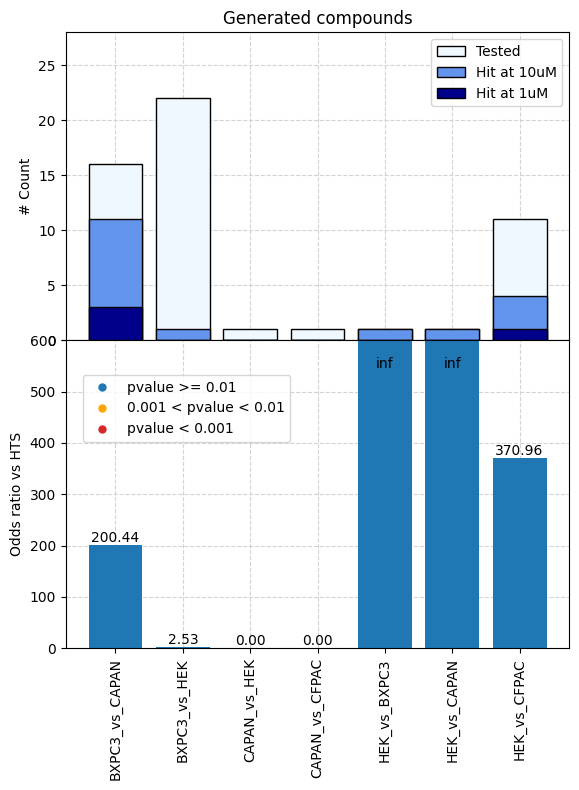

In [ ]:
# Create the figure and subplots with shared x-axis and tight layout
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(6.5, 8), gridspec_kw={"hspace": 0}
)

# Create bar plots for each subplot
ax1.bar(
    np.arange(len(bars10um_generated)),
    total_generated,
    color="aliceblue",
    label="Tested",
    edgecolor="black",
    zorder=2,
)
ax1.bar(
    np.arange(len(bars10um_generated)),
    bars10um_generated,
    color="cornflowerblue",
    label="Hit at 10uM",
    edgecolor="black",
    zorder=3,
)
ax1.bar(
    np.arange(len(bars10um_generated)),
    bars1um_generated,
    color="darkblue",
    label="Hit at 1uM",
    edgecolor="black",
    zorder=4,
)
ax2.bar(
    x=np.arange(0, len(enrichements_generated), 1),
    height=odss_new_generated,
    zorder=2,  # , color=color_odds
)

# Set labels and title for the first subplot only
ax1.set_xlabel("")  # Empty string to remove x-axis label
ax1.set_ylabel("# Count")
ax1.set_title("Generated compounds")
ax1.set_ylim(0, 28)
ax1.legend()
# Set labels but remove title for the second subplot
ax2.set_ylabel("Odds ratio vs HTS")
ax2.set_title("")  # Empty string to remove title


# Add text annotations on top of each bar
for i, value in enumerate(odds_generated):
    ax2.text(
        i,
        min(odds_generated[i] + 0.05, 540.74),
        "%.2f" % value,
        ha="center",
        va="bottom",
    )

# Legend
legend_elements = [
    Line2D(
        [],
        [],
        marker="o",
        linestyle="None",
        color="tab:blue",
        label="pvalue >= 0.01",
        markerfacecolor="tab:blue",
        markersize=5,
    ),
    Line2D(
        [],
        [],
        marker="o",
        linestyle="None",
        color="orange",
        label="0.001 < pvalue < 0.01",
        markerfacecolor="orange",
        markersize=5,
    ),
    Line2D(
        [],
        [],
        marker="o",
        linestyle="None",
        color="tab:red",
        label="pvalue < 0.001",
        markerfacecolor="tab:red",
        markersize=5,
    ),
]
plt.legend(handles=legend_elements, bbox_to_anchor=(0.46, 0.91))

ax2.set_ylim(0, 600)
ax2.grid(linestyle="--", color="lightgrey", zorder=0)
ax1.grid(linestyle="--", color="lightgrey", zorder=0)

# plt.title("Generated compounds vs HTS or confirmation")

# Hide ticks and labels on the bottom (x-axis) of both subplots
plt.gca().xaxis.set_major_locator(
    plt.NullLocator()
)  # Hide x-axis ticks for all subplots
plt.gca().xaxis.set_major_formatter(
    plt.NullFormatter()
)  # Hide x-axis labels for all subplots

plt.xticks(
    np.arange(0, len(enrichements_generated), 1),
    [c[0] + "_vs_" + c[1] for c in combinations],
    rotation=90,
)  # Change the x tick labels
# Show the combined plot
plt.show()

### IRB predicted vs random

In [ ]:
global_df_unique

,IDNUMBER,SMILES,BXPC3,CAPAN,HEK,CFPAC
0,0234-0037,Nc1c(C(=O)O)cc(Br)c2c1C(=O)c1ccccc1C2=O,NaN,1.0,0.0,NaN
1,0310-0156,O=C(c(cccc1)c1-c1c2c(cc3)no1)c2c3NCCCl,NaN,1.0,0.0,NaN
2,1488-2470,Nc1c(Br)cc(Cl)c2c1C(=O)c1ccccc1C2=O,NaN,1.0,0.0,NaN
3,2082-0205,COc1cccc(/C=C/C(NC(NC2=O)=O)=C2[N+]([O-])=O)c1,NaN,1.0,0.0,NaN
4,4204-0050,O=C1C(Nc2cccc(I)c2)=C(N2CCCCC2)C(=O)c2ccccc21,NaN,1.0,0.0,NaN
5,4204-0078,CC(=O)N(C1=C(N2CCCC2)C(=O)c2ccccc2C1=O)c1ccc(C...,NaN,1.0,0.0,NaN
6,4400-0080,Cc1ccc(ccc(/C=C/c(cc2)ccc2N(C)C)[n+]2CCCS([O-]...,NaN,1.0,0.0,NaN
7,4456-3685,O=C(O)c1cccc(S(=O)(=O)/N=C2/C=C(NS(=O)(=O)c3cc...,NaN,1.0,0.0,NaN
8,4522-0018,O=C1c2ccccc2C(=O)c2c(NCC3CCCO3)cccc21,NaN,1.0,0.0,NaN
9,4896-4876,Cc(cc(C(c(ccc1ccc(C)nc11)c1O)Nc1nc(C)ccc1)cc1)...,NaN,1.0,NaN,0.0


In [ ]:
ids = [x.replace('-','_') for x in global_df_unique['IDNUMBER']]
print(sum(np.isin(ids, results['Sample'])))
len(np.unique(np.array(ids)[np.isin(ids, results['Sample'])]))

56


56

In [ ]:
enrichements_irb = []
for c in combinations:
    pos_cll = c[0]
    neg_cll = c[1]
    enrichment_df = pd.DataFrame()
    hts_to_compare = hts.copy()
    hts_to_compare = hts_to_compare[['Supplier Ref', pos_cll + "_vs_" + neg_cll]].dropna()

    expected = (
        global_df_unique[["IDNUMBER", pos_cll, neg_cll]]
        .sort_values(by="IDNUMBER")
        .dropna()
    )
    expected = expected[np.logical_and(expected[pos_cll] == 1, expected[neg_cll] == 0)]
    if True:
        enrichment_df["cpd"] = list(hts_to_compare["Supplier Ref"].values) + list(
            expected["IDNUMBER"].values
        )
        enrichment_df["Active"] = list(hts_to_compare[pos_cll + "_vs_" + neg_cll].values) + [
            (
                1
                if np.isin(
                    i,
                    r10uM_binary.cpd[
                        np.logical_and(
                            r10uM_binary[pos_cll + "_mean2closest"] == 1,
                            r10uM_binary[neg_cll + "_mean2closest"] == 0,
                        )
                    ],
                )
                else 0
            )
            for i in expected["IDNUMBER"].values
        ]

        enrichment_df["Generated"] = [0] * len(hts_to_compare) + [1] * len(expected)

    else:
        enrichment_df["cpd"] = list(confirmation["Supplier Ref"].values) + list(
            expected["IDNUMBER"].values
        )
        enrichment_df["Active"] = list(
            confirmation[pos_cll + "_vs_" + neg_cll].values
        ) + [
            (
                1
                if np.isin(
                    i,
                    r10uM_binary.cpd[
                        np.logical_and(
                            r10uM_binary[pos_cll + "_mean2closest"] == 1,
                            r10uM_binary[neg_cll + "_mean2closest"] == 0,
                        )
                    ],
                )
                else 0
            )
            for i in expected["IDNUMBER"].values
        ]

        enrichment_df["Generated"] = [0] * len(confirmation) + [1] * len(expected)

    confusion_matrix = metrics.confusion_matrix(
        enrichment_df["Generated"], enrichment_df["Active"].values
    )
    fisher = stats.fisher_exact(confusion_matrix)
    print(c, fisher)
    print(confusion_matrix)
    enrichements_irb.append(fisher)

['BXPC3', 'CAPAN'] SignificanceResult(statistic=15.184722222222222, pvalue=0.07413355955414007)
[[10933   120]
 [    6     1]]
['BXPC3', 'HEK'] SignificanceResult(statistic=13.083333333333334, pvalue=0.10376506401883082)
[[314   6]
 [  4   1]]
['CAPAN', 'HEK'] SignificanceResult(statistic=6.24, pvalue=0.012006597554786936)
[[312   8]
 [ 25   4]]
['CAPAN', 'CFPAC'] SignificanceResult(statistic=36.261373035566585, pvalue=1.2080291495405173e-05)
[[10960    93]
 [   13     4]]
['HEK', 'BXPC3'] SignificanceResult(statistic=10.928571428571429, pvalue=0.13334331358668913)
[[306  14]
 [  2   1]]
['HEK', 'CAPAN'] SignificanceResult(statistic=15.842105263157896, pvalue=0.12054720303399699)
[[301  19]
 [  1   1]]
['HEK', 'CFPAC'] SignificanceResult(statistic=0.0, pvalue=1.0)
[[303  17]
 [  4   0]]


0.07413355955414007
0.10376506401883082
0.012006597554786936
1.2080291495405173e-05
0.13334331358668913
0.12054720303399699
1.0


(0.0, 620.0)

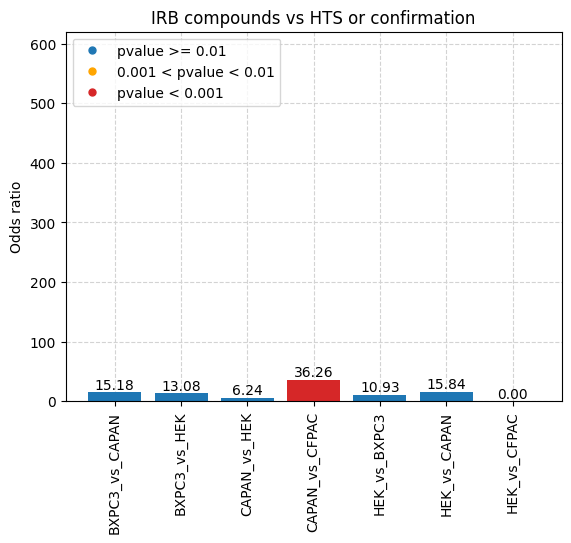

In [ ]:
pvalues = [enrichement[1] for enrichement in enrichements_irb]
odds_irb = [enrichement[0] for enrichement in enrichements_irb]

color = []
for p in pvalues:
    print(p)
    if p > 0.01:
        color.append("tab:blue")
    elif p <= 0.001:
        color.append("tab:red")
    else:
        color.append("tab:orange")

plt.bar(
    x=np.arange(0, len(enrichements_irb), 1), height=odds_irb, zorder=2, color=color
)

plt.xticks(
    np.arange(0, len(enrichements_irb), 1),
    [c[0] + "_vs_" + c[1] for c in combinations],
    rotation=90,
)  # Change the x tick labels

# Add text annotations on top of each bar
for i, value in enumerate(odds_irb):
    plt.text(i, odds_irb[i] + 0.05, "%.2f" % value, ha="center", va="bottom")

# Legend
legend_elements = [
    Line2D(
        [],
        [],
        marker="o",
        linestyle="None",
        color="tab:blue",
        label="pvalue >= 0.01",
        markerfacecolor="tab:blue",
        markersize=5,
    ),
    Line2D(
        [],
        [],
        marker="o",
        linestyle="None",
        color="orange",
        label="0.001 < pvalue < 0.01",
        markerfacecolor="orange",
        markersize=5,
    ),
    Line2D(
        [],
        [],
        marker="o",
        linestyle="None",
        color="tab:red",
        label="pvalue < 0.001",
        markerfacecolor="tab:red",
        markersize=5,
    ),
]
plt.legend(handles=legend_elements, loc="upper left")

plt.grid(linestyle="--", color="lightgrey", zorder=0)
plt.title("IRB compounds vs HTS or confirmation")
plt.ylabel("Odds ratio")
plt.ylim(0, 620)

#### Combined plot hits + enrichment

In [ ]:
pos_clls, neg_clls, true, true1um, total_irb = [], [], [], [], []
nirb_tested = []
cpds_that_work_10um_irb = {}
cpds_that_work_1um_irb = {}
for c in combinations:
    print(c)
    pos_cll = c[0]
    neg_cll = c[1]
    pos_clls.append(pos_cll)
    neg_clls.append(neg_cll)
    expected = (
        global_df_unique[["IDNUMBER", pos_cll, neg_cll]]
        .sort_values(by="IDNUMBER")
        .dropna()
    )
    expected = expected[np.logical_and(expected[pos_cll] == 1, expected[neg_cll] == 0)]

    gotten = r10uM_binary[r10uM_binary["cpd"].isin(expected["IDNUMBER"])][
        ["cpd", pos_cll + "_mean2closest", neg_cll + "_mean2closest"]
    ].sort_values(by="cpd")
    nirb_tested += list(gotten['cpd'].values)

    gotten_1um = r1uM_binary[r1uM_binary["cpd"].isin(expected["IDNUMBER"])][
        ["cpd", pos_cll + "_mean2closest", neg_cll + "_mean2closest"]
    ].sort_values(by="cpd")

    gotten_true = gotten[
        np.logical_and(
            gotten[pos_cll + "_mean2closest"] == 1,
            gotten[neg_cll + "_mean2closest"] == 0,
        )
    ]

    gotten_true_1um = gotten_1um[
        np.logical_and(
            gotten_1um[pos_cll + "_mean2closest"] == 1,
            gotten_1um[neg_cll + "_mean2closest"] == 0,
        )
    ]

    cpds_that_work_10um_irb[pos_cll + "_vs_" + neg_cll] = gotten_true["cpd"].values
    cpds_that_work_1um_irb[pos_cll + "_vs_" + neg_cll] = gotten_true_1um["cpd"].values

    print("True 10uM:", gotten_true.shape[0])
    print("True 1uM:", gotten_true_1um.shape[0])
    print("Total:", gotten.shape[0])
    true.append(gotten_true.shape[0])
    true1um.append(gotten_true_1um.shape[0])
    total_irb.append(gotten.shape[0])

['BXPC3', 'CAPAN']
True 10uM: 1
True 1uM: 1
Total: 7
['BXPC3', 'HEK']
True 10uM: 1
True 1uM: 0
Total: 5
['CAPAN', 'HEK']
True 10uM: 4
True 1uM: 0
Total: 27
['CAPAN', 'CFPAC']
True 10uM: 4
True 1uM: 0
Total: 17
['HEK', 'BXPC3']
True 10uM: 1
True 1uM: 0
Total: 3
['HEK', 'CAPAN']
True 10uM: 1
True 1uM: 0
Total: 2
['HEK', 'CFPAC']
True 10uM: 0
True 1uM: 0
Total: 4


In [ ]:
total_irb

[7, 5, 27, 17, 3, 2, 4]

In [ ]:
len(np.unique(nirb_tested))

56

In [ ]:
# Data to plot
bars10um_irb = []
bars1um_irb = []
barstotal_irb = total_irb  ##  comes from gotten, that is the same for all the plots before when comparing to expected results
for c in combinations:
    pos_cll = c[0]
    neg_cll = c[1]
    bars10um_irb.append(len(cpds_that_work_10um_irb[c[0] + "_vs_" + c[1]]))
    bars1um_irb.append(len(cpds_that_work_1um_irb[c[0] + "_vs_" + c[1]]))

pvalues = [enrichement[1] for enrichement in enrichements_irb]
odds_irb = [enrichement[0] for enrichement in enrichements_irb]
odss_new_irb = odds_irb.copy()
for i in range(len(odds_irb)):
    if odss_new_irb[i] == float("inf"):
        odss_new_irb[i] = 650

color_odds = []
for p in pvalues:
    print(p)
    if p > 0.01:
        color_odds.append("tab:blue")
    elif p <= 0.001:
        color_odds.append("tab:red")
    else:
        color_odds.append("tab:orange")

0.07413355955414007
0.10376506401883082
0.012006597554786936
1.2080291495405173e-05
0.13334331358668913
0.12054720303399699
1.0


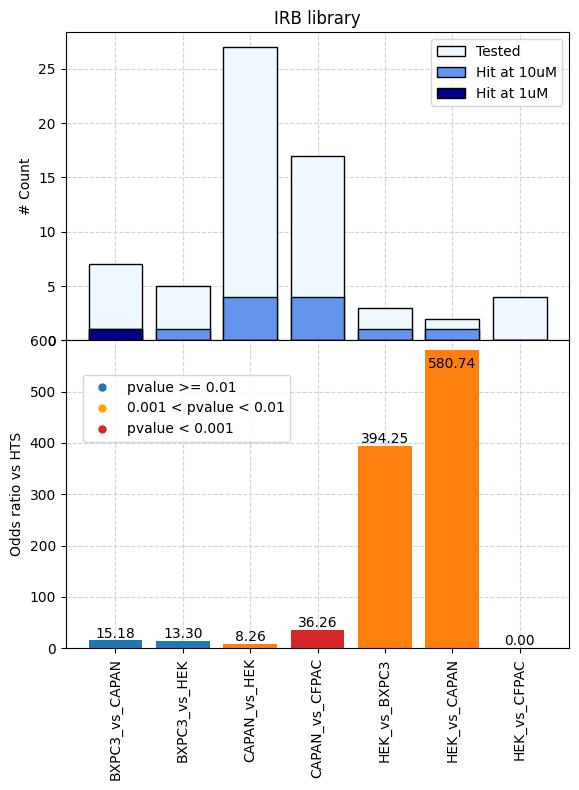

In [ ]:
# Create the figure and subplots with shared x-axis and tight layout
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(6.5, 8), gridspec_kw={"hspace": 0}
)

# Create bar plots for each subplot
ax1.bar(
    np.arange(len(bars10um_irb)),
    total_irb,
    color="aliceblue",
    label="Tested",
    edgecolor="black",
    zorder=2,
)
ax1.bar(
    np.arange(len(bars10um_irb)),
    bars10um_irb,
    color="cornflowerblue",
    label="Hit at 10uM",
    edgecolor="black",
    zorder=3,
)
ax1.bar(
    np.arange(len(bars10um_irb)),
    bars1um_irb,
    color="darkblue",
    label="Hit at 1uM",
    edgecolor="black",
    zorder=4,
)
ax2.bar(
    x=np.arange(0, len(enrichements_irb), 1),
    height=odss_new_irb,
    zorder=2,
    color=color_odds,
)

# Set labels and title for the first subplot only
ax1.set_xlabel("")  # Empty string to remove x-axis label
ax1.set_ylabel("# Count")
ax1.set_title("IRB library")
ax1.legend()
# Set labels but remove title for the second subplot
ax2.set_ylabel("Odds ratio vs HTS")
ax2.set_title("")  # Empty string to remove title


# Add text annotations on top of each bar
for i, value in enumerate(odds_irb):
    ax2.text(
        i, min(odds_irb[i] + 0.05, 540.74), "%.2f" % value, ha="center", va="bottom"
    )

# Legend
legend_elements = [
    Line2D(
        [],
        [],
        marker="o",
        linestyle="None",
        color="tab:blue",
        label="pvalue >= 0.01",
        markerfacecolor="tab:blue",
        markersize=5,
    ),
    Line2D(
        [],
        [],
        marker="o",
        linestyle="None",
        color="orange",
        label="0.001 < pvalue < 0.01",
        markerfacecolor="orange",
        markersize=5,
    ),
    Line2D(
        [],
        [],
        marker="o",
        linestyle="None",
        color="tab:red",
        label="pvalue < 0.001",
        markerfacecolor="tab:red",
        markersize=5,
    ),
]
plt.legend(handles=legend_elements, bbox_to_anchor=(0.46, 0.91))

ax2.set_ylim(0, 600)
ax2.grid(linestyle="--", color="lightgrey", zorder=0)
ax1.grid(linestyle="--", color="lightgrey", zorder=0)

# plt.title("Generated compounds vs HTS or confirmation")

# Hide ticks and labels on the bottom (x-axis) of both subplots
plt.gca().xaxis.set_major_locator(
    plt.NullLocator()
)  # Hide x-axis ticks for all subplots
plt.gca().xaxis.set_major_formatter(
    plt.NullFormatter()
)  # Hide x-axis labels for all subplots

plt.xticks(
    np.arange(0, len(enrichements_irb), 1),
    [c[0] + "_vs_" + c[1] for c in combinations],
    rotation=90,
)  # Change the x tick labels
# Show the combined plot
plt.show()

## Plot together number of hits for IRB and generated compounds

In [ ]:
xlabels = [
    "BXPC3 vs CAPAN2",
    "BXPC3 vs HEK293",
    "CAPAN2 vs HEK293",
    "CAPAN2 vs CFPAC1",
    "HEK293 vs BXPC3",
    "HEK293 vs CAPAN2",
    "HEK293 vs CFPAC1",
]

/tmp/ipykernel_211941/887672170.py:133: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axis.set_ylim(-1.0, 1500)  # Adjust these values as needed
/tmp/ipykernel_211941/887672170.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


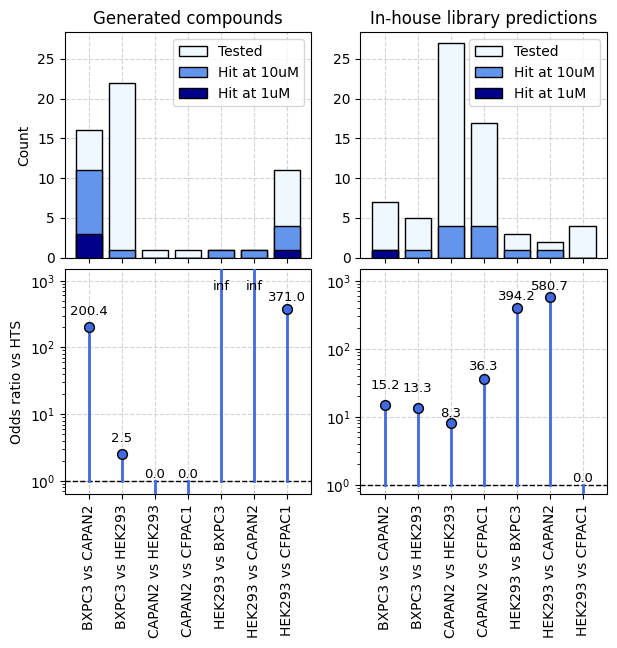

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(2, 2, sharex=True, figsize=(7, 6), gridspec_kw={"hspace": 0.05})

ax1, ax2, ax3, ax4 = ax.flatten()

# Create bar plots for generated compounds (ax1)
ax1.bar(
    np.arange(len(bars10um_generated)),
    total_generated,
    color="aliceblue",
    label="Tested",
    edgecolor="black",
    zorder=3,
)
ax1.bar(
    np.arange(len(bars10um_generated)),
    bars10um_generated,
    color="cornflowerblue",
    label="Hit at 10uM",
    edgecolor="black",
    zorder=4,
)
ax1.bar(
    np.arange(len(bars10um_generated)),
    bars1um_generated,
    color="darkblue",
    label="Hit at 1uM",
    edgecolor="black",
    zorder=5,
)
ax1.legend()

# Create bar plots for IRB compounds (ax2)
ax2.bar(
    np.arange(len(bars10um_irb)),
    total_irb,
    color="aliceblue",
    label="Tested",
    edgecolor="black",
    zorder=3,
)
ax2.bar(
    np.arange(len(bars10um_irb)),
    bars10um_irb,
    color="cornflowerblue",
    label="Hit at 10uM",
    edgecolor="black",
    zorder=4,
)
ax2.bar(
    np.arange(len(bars10um_irb)),
    bars1um_irb,
    color="darkblue",
    label="Hit at 1uM",
    edgecolor="black",
    zorder=5,
)
ax2.legend()

# Set labels and title for top plots
ax1.set_xlabel("")
ax1.set_ylabel("Count")
ax1.set_title("Generated compounds")

ax2.set_xlabel("")
ax2.set_title("In-house library predictions")

# Create lollipop plot for generated compounds (ax3)
colors = ["royalblue"] * len(odss_new_generated)
for i, (x, y) in enumerate(zip(np.arange(len(odss_new_generated)), odss_new_generated)):
    ax3.plot([x, x], [1, y], color=colors[i], linewidth=2, zorder=3)
    ax3.scatter(x, y, color=colors[i], s=50, zorder=4, edgecolor="black")

# Set labels for ax3
ax3.set_ylabel("Odds ratio vs HTS")
ax3.set_title("")

# Create lollipop plot for IRB compounds (ax4)
for i, (x, y) in enumerate(zip(np.arange(len(odss_new_irb)), odss_new_irb)):
    ax4.plot([x, x], [1, y], color=colors[i], linewidth=2, zorder=3)
    ax4.scatter(x, y, color=colors[i], s=50, zorder=4, edgecolor="black")

# Set labels for ax4
ax4.set_title("")

# Set x-ticks for bottom plots
for axis in [ax3, ax4]:
    axis.set_xticks(np.arange(0, len(combinations), 1), xlabels, rotation=90)

# Add grids to all plots
for axis in [ax1, ax2, ax3, ax4]:
    axis.grid(True, linestyle="--", color="lightgrey", zorder=0)

# Set same y-limits for top plots
y_max_top = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(0, y_max_top)
ax2.set_ylim(0, y_max_top)

# Modify bottom plots
for axis, data in [(ax3, odds_generated), (ax4, odds_irb)]:
    # Set logarithmic scale
    axis.set_yscale("log")

    # Add horizontal line at y=1
    axis.axhline(y=1, color="black", linestyle="--", linewidth=1, zorder=2)

    # Add text annotations
    for i, value in enumerate(data):
        if value == 0:
            y_offset = 1
        elif value < 10:
            y_offset = 0.9
        elif value < 100:
            y_offset = 8
        else:
            y_offset = 80

        if value > 1000:
            axis.text(i, 580 + y_offset, f"inf", ha="center", va="bottom", fontsize=9.5)
        else:
            axis.text(
                i,
                value + y_offset,
                f"{value:.1f}",
                ha="center",
                va="bottom",
                fontsize=9.5,
            )

    # Set y-limits
    axis.set_ylim(-1.0, 1500)  # Adjust these values as needed

plt.tight_layout()
# plt.savefig(
#    "validation_generated_and_irb_compounds.svg",
#    format="svg",
#    dpi=300,
#    bbox_inches="tight",
# )

## Patrick's way

In [ ]:
cpds_that_work_mean2closest_10uM_generated

{'BXPC3_vs_CAPAN': array(['MCULE-1329921853', 'MCULE-1477843803', 'MCULE-2040607482',
        'MCULE-2326121181', 'MCULE-3283587573', 'MCULE-3551346871',
        'MCULE-5074289166', 'MCULE-5830374764', 'MCULE-6814427357',
        'MCULE-8454725046', 'Z3025619666'], dtype=object),
 'BXPC3_vs_HEK': array(['MCULE-5282728374-0'], dtype=object),
 'CAPAN_vs_HEK': array([], dtype=object),
 'CAPAN_vs_CFPAC': array([], dtype=object),
 'HEK_vs_BXPC3': array(['MCULE-6767457754'], dtype=object),
 'HEK_vs_CAPAN': array(['MCULE-6767457754'], dtype=object),
 'HEK_vs_CFPAC': array(['MCULE-1493650762', 'MCULE-1508380250', 'MCULE-2557790400',
        'MCULE-8388595355'], dtype=object)}

In [ ]:
# Data to plot
bars_generated = []
enrichements_generated = []
barstotal_generated = total_generated  ##  comes from gotten, that is the same for all the plots before when comparing to expected results
for c in combinations:
    pos_cll = c[0]
    neg_cll = c[1]
    enrichment_df = pd.DataFrame()
    hts_to_compare = hts.copy()
    hts_to_compare = hts_to_compare[['Supplier Ref', pos_cll + "_vs_" + neg_cll]].dropna()

    cpds_that_work = np.unique(
        list(cpds_that_work_mean2closest_10uM_generated[c[0] + "_vs_" + c[1]])
        + list(cpds_that_work_mean_1uM_generated[c[0] + "_vs_" + c[1]])
    )
    bars_generated.append(len(cpds_that_work))

    expected = (
        expected_results[["Query Mcule ID", pos_cll, neg_cll]]
        .sort_values(by="Query Mcule ID")
        .dropna()
    )

    expected = expected[np.logical_and(expected[pos_cll] == 1, expected[neg_cll] == 0)]

    enrichment_df["cpd"] = list(hts_to_compare["Supplier Ref"].values) + list(
        expected["Query Mcule ID"].values
    )
    enrichment_df["Active"] = list(hts_to_compare[pos_cll + "_vs_" + neg_cll].values) + [
        (
            1
            if np.isin(
                i,
                cpds_that_work,
            )
            else 0
        )
        for i in expected["Query Mcule ID"].values
    ]
    enrichment_df["Generated"] = [0] * len(hts_to_compare) + [1] * len(expected)

    confusion_matrix = metrics.confusion_matrix(
        enrichment_df["Generated"], enrichment_df["Active"].values
    )
    fisher = stats.fisher_exact(confusion_matrix)
    print(c, fisher)
    print(confusion_matrix)
    enrichements_generated.append(fisher)


pvalues = [enrichement[1] for enrichement in enrichements_generated]
odds_generated = [enrichement[0] for enrichement in enrichements_generated]
odss_new_generated = odds_generated.copy()
for i in range(len(odds_generated)):
    if odss_new_generated[i] == float("inf"):
        odss_new_generated[i] = 10000

['BXPC3', 'CAPAN'] SignificanceResult(statistic=273.325, pvalue=8.689889075636727e-21)
[[10933   120]
 [    4    12]]
['BXPC3', 'HEK'] SignificanceResult(statistic=2.492063492063492, pvalue=0.37481384874164264)
[[314   6]
 [ 21   1]]
['CAPAN', 'HEK'] SignificanceResult(statistic=0.0, pvalue=1.0)
[[312   8]
 [  1   0]]
['CAPAN', 'CFPAC'] SignificanceResult(statistic=0.0, pvalue=1.0)
[[10960    93]
 [    1     0]]
['HEK', 'BXPC3'] SignificanceResult(statistic=inf, pvalue=0.04672897196261682)
[[306  14]
 [  0   1]]
['HEK', 'CAPAN'] SignificanceResult(statistic=inf, pvalue=0.062305295950155756)
[[301  19]
 [  0   1]]
['HEK', 'CFPAC'] SignificanceResult(statistic=14.852941176470589, pvalue=0.0002898861552524602)
[[303  17]
 [  6   5]]


In [ ]:
cpds_that_work

array(['MCULE-1493650762', 'MCULE-1508380250', 'MCULE-2557790400',
       'MCULE-7455265610', 'MCULE-8388595355'], dtype='<U16')

In [ ]:
df_gen = pd.read_csv(
    "/aloy/home/grojas/tesis/cell_line_specific_NCEs/scripts/generative_models/09_2023_generation_for_paper/experimental_validation/jesus_experiments/deltas_and_ratios_generated_mols_dose_response_validatio.csv"
)
df_irb = pd.read_csv(
    "/aloy/home/grojas/tesis/cell_line_specific_NCEs/scripts/generative_models/09_2023_generation_for_paper/experimental_validation/jesus_experiments/deltas_and_ratios_irb_mols_dose_response_validatio.csv"
)

In [ ]:
df_irb.head()

,Compound,Concentration,affected_cell,unaffected_cell,deltas_affected,deltas_unaffected,ratio
0,8020-7617,10uM,BXPC3,CAPAN,27.41,-7.28,2.089754
1,8020-7617,1uM,BXPC3,CAPAN,-3.80,-25.22,3.195423
2,D470-1924,10uM,BXPC3,HEK,-26.25,-42.16,0.000000
3,5591-1963,10uM,CAPAN,CFPAC,0.22,-26.06,3.461624
4,5994-0447,10uM,CAPAN,CFPAC,11.19,-23.38,3.606684


In [ ]:
df_irb.Compound.nunique()

11

In [ ]:
df_gen.head(1)

,Compound,Concentration,affected_cell,unaffected_cell,deltas_affected,deltas_unaffected,ratio
0,MCULE-1153524502,1uM,BXPC3,CAPAN,32.57,-22.46,6.459716


In [ ]:
df_gen_aux = df_gen.drop(columns=["ratio"]).copy()

# Convert concentration to categorical type for proper sorting
df_gen_aux["Concentration"] = pd.Categorical(
    df_gen_aux["Concentration"], categories=["10uM", "1uM"], ordered=True
)

# Sort by concentration (descending) and reset index
df_gen_aux = df_gen_aux.sort_values("Concentration", ascending=False).reset_index(
    drop=True
)

# Drop duplicates, keeping the first occurrence (which will be the higher concentration)
df_gen_aux = df_gen_aux.drop_duplicates(
    subset=["Compound", "affected_cell", "unaffected_cell"], keep="first"
)

# Reset the index of the final DataFrame
df_gen_aux = df_gen_aux.reset_index(drop=True)
df_gen_aux = df_gen_aux.sort_values(by=["affected_cell", "unaffected_cell", "Compound"])

In [ ]:
df_irb_aux = df_irb.drop(columns=["ratio"]).copy()

# Convert concentration to categorical type for proper sorting
df_irb_aux["Concentration"] = pd.Categorical(
    df_irb_aux["Concentration"], categories=["10uM", "1uM"], ordered=True
)

# Drop duplicates, keeping the first occurrence (which will be the higher concentration)
df_irb_aux = df_irb_aux.drop_duplicates(
    subset=["Compound", "affected_cell", "unaffected_cell"], keep="first"
)

# Reset the index of the final DataFrame
df_irb_aux = df_irb_aux.reset_index(drop=True)
df_irb_aux = df_irb_aux.sort_values(by=["affected_cell", "unaffected_cell", "Compound"])

/tmp/ipykernel_26262/1553501505.py:75: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(-1.0, 1500)  # Adjust these values as needed


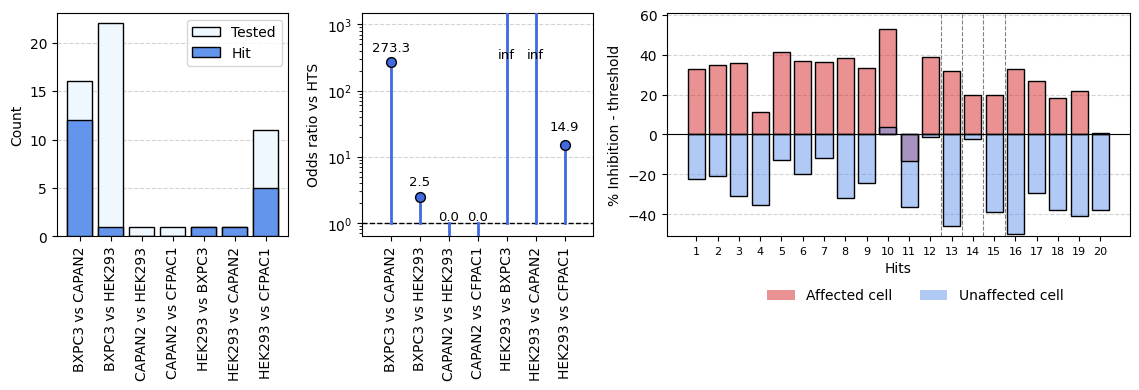

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, figsize=(11.5, 4), gridspec_kw={"width_ratios": [0.25, 0.25, 0.5]}
)

## Create bar plots for generated compounds (ax1)
xlabels = [
    "BXPC3 vs CAPAN2",
    "BXPC3 vs HEK293",
    "CAPAN2 vs HEK293",
    "CAPAN2 vs CFPAC1",
    "HEK293 vs BXPC3",
    "HEK293 vs CAPAN2",
    "HEK293 vs CFPAC1",
]

ax1.bar(
    np.arange(len(bars_generated)),
    total_generated,
    color="aliceblue",
    label="Tested",
    edgecolor="black",
    zorder=3,
)
ax1.bar(
    np.arange(len(bars_generated)),
    bars_generated,
    color="cornflowerblue",
    label="Hit",
    edgecolor="black",
    zorder=4,
)

ax1.legend()
ax1.set_ylabel("Count")

## Create lollipop plot for generated compounds
colors = ["royalblue"] * len(odss_new_generated)
for i, (x, y) in enumerate(zip(np.arange(len(odss_new_generated)), odss_new_generated)):
    ax2.plot([x, x], [1, y], color=colors[i], linewidth=2, zorder=3)
    ax2.scatter(x, y, color=colors[i], s=50, zorder=4, edgecolor="black")

# Set labels for ax2
ax2.set_ylabel("Odds ratio vs HTS")

# Set logarithmic scale
ax2.set_yscale("log")

# Add horizontal line at y=1
ax2.axhline(y=1, color="black", linestyle="--", linewidth=1, zorder=2)

# Add text annotations
for i, value in enumerate(odds_generated):
    if value == 0:
        y_offset = 1
    elif value < 10:
        y_offset = 0.9
    elif value < 100:
        y_offset = 8
    else:
        y_offset = 80

    if value > 1000:
        ax2.text(i, 200 + y_offset, f"inf", ha="center", va="bottom", fontsize=9.5)
    else:
        ax2.text(
            i,
            value + y_offset,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=9.5,
        )

# Set xy-limits
ax2.set_ylim(-1.0, 1500)  # Adjust these values as needed
ax2.set_xlim(-1.0, 7)

# Set x-ticks for plots 1 and 2
for axis in [ax1, ax2]:
    axis.set_xticks(np.arange(0, len(combinations), 1), xlabels, rotation=90)


## Plot generated molecules - differences to threshold
# Color
colors_un = "cornflowerblue"
colors_af = "tab:red"
ax3.bar(
    np.arange(0, len(df_gen_aux), 1),
    df_gen_aux["deltas_affected"],
    align="center",
    alpha=0.5,
    color=colors_af,
    label="Affected cell",
    zorder=2,
)
ax3.bar(
    np.arange(0, len(df_gen_aux), 1),
    df_gen_aux["deltas_unaffected"],
    align="center",
    alpha=0.5,
    color=colors_un,
    label="Unaffected cell",
    zorder=2,
)
ax3.bar(
    np.arange(0, len(df_gen_aux), 1),
    df_gen_aux["deltas_affected"],
    align="center",
    fill=False,
    edgecolor="black",
    zorder=2,
)
ax3.bar(
    np.arange(0, len(df_gen_aux), 1),
    df_gen_aux["deltas_unaffected"],
    align="center",
    fill=False,
    edgecolor="black",
    zorder=2,
)
# ax3.legend()
# Create a separate legend
handles, labels = ax3.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.8, 0.2),
    ncol=2,
    frameon=False,
)

ax3.axvline(x=11.5, color="grey", linestyle="--", linewidth=0.8)
ax3.axvline(x=12.5, color="grey", linestyle="--", linewidth=0.8)
ax3.axvline(x=13.5, color="grey", linestyle="--", linewidth=0.8)
ax3.axvline(x=14.5, color="grey", linestyle="--", linewidth=0.8)

ax3.set_ylim(-51, 61)
# X labels for bottom plots
xlabels = []
for i in range(len(df_gen_aux)):
    c = df_gen_aux.Compound.values[i]
    if df_gen_aux.Concentration.values[i] == "1uM":
        c = c + " (1uM)"
    xlabels.append(c)

# ax3.set_xticks(ticks=np.arange(0, len(df_gen), 1), labels=xlabels, rotation=90)
ax3.axhline(y=0, color="black", linestyle="-", linewidth=0.8)
ax3.set_xlabel("Hits")
# ax3.set_xticklabels([])
# ax3.set_xticks([])
ax3.set_xticks(
    ticks=np.arange(0, len(df_gen_aux), 1),
    labels=np.arange(1, len(df_gen_aux)+1, 1),
    fontsize=8,
)

ax3.set_ylabel("% Inhibition - threshold")

for ax in [ax1, ax2, ax3]:
    ax.grid(axis="y", linestyle="--", color="lightgrey", zorder=0)
plt.tight_layout()

plt.savefig(
    "validation_generated_compounds_corrected.svg",
    format="svg",
    dpi=300,
    bbox_inches="tight",
)

In [ ]:
df_gen_aux

,Compound,Concentration,affected_cell,unaffected_cell,deltas_affected,deltas_unaffected
0,MCULE-1153524502,1uM,BXPC3,CAPAN,32.57,-22.46
14,MCULE-1329921853,10uM,BXPC3,CAPAN,34.98,-20.85
13,MCULE-1477843803,10uM,BXPC3,CAPAN,35.80,-30.76
15,MCULE-2040607482,10uM,BXPC3,CAPAN,11.20,-35.42
4,MCULE-2326121181,10uM,BXPC3,CAPAN,41.18,-12.97
5,MCULE-3283587573,10uM,BXPC3,CAPAN,36.65,-19.86
18,MCULE-3551346871,10uM,BXPC3,CAPAN,36.55,-11.58
17,MCULE-5074289166,10uM,BXPC3,CAPAN,38.20,-31.86
16,MCULE-5830374764,10uM,BXPC3,CAPAN,33.56,-24.26
1,MCULE-6814427357,1uM,BXPC3,CAPAN,52.62,3.65


In [ ]:
p_values_irb

NameError: name 'p_values_irb' is not defined

/tmp/ipykernel_26262/2605150993.py:75: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(-1.0, 1500)  # Adjust these values as needed


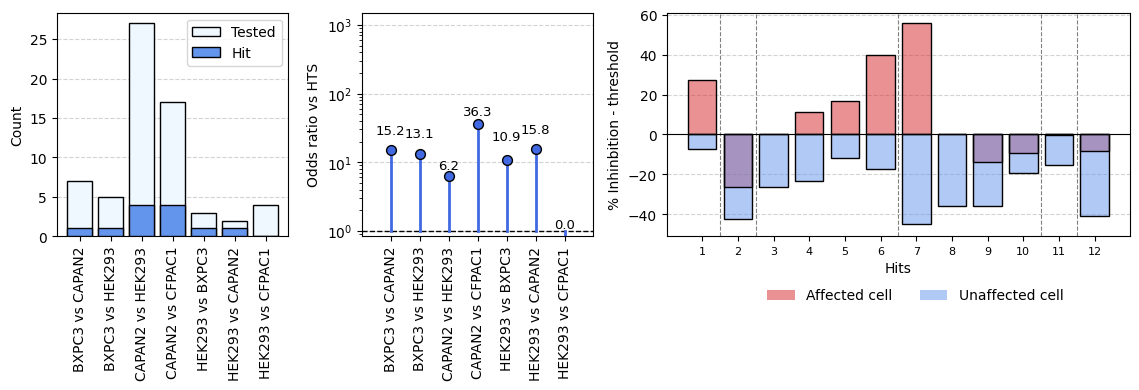

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, figsize=(11.5, 4), gridspec_kw={"width_ratios": [0.25, 0.25, 0.5]}
)

## Create bar plots for generated compounds (ax1)
xlabels = [
    "BXPC3 vs CAPAN2",
    "BXPC3 vs HEK293",
    "CAPAN2 vs HEK293",
    "CAPAN2 vs CFPAC1",
    "HEK293 vs BXPC3",
    "HEK293 vs CAPAN2",
    "HEK293 vs CFPAC1",
]

ax1.bar(
    np.arange(len(total_irb)),
    total_irb,
    color="aliceblue",
    label="Tested",
    edgecolor="black",
    zorder=3,
)
ax1.bar(
    np.arange(len(bars10um_irb)),
    bars10um_irb,
    color="cornflowerblue",
    label="Hit",
    edgecolor="black",
    zorder=4,
)

ax1.legend()
ax1.set_ylabel("Count")

## Create lollipop plot for generated compounds
colors = ["royalblue"] * len(odss_new_irb)
for i, (x, y) in enumerate(zip(np.arange(len(odss_new_irb)), odss_new_irb)):
    ax2.plot([x, x], [1, y], color=colors[i], linewidth=2, zorder=3)
    ax2.scatter(x, y, color=colors[i], s=50, zorder=4, edgecolor="black")

# Set labels for ax2
ax2.set_ylabel("Odds ratio vs HTS")

# Set logarithmic scale
ax2.set_yscale("log")

# Add horizontal line at y=1
ax2.axhline(y=1, color="black", linestyle="--", linewidth=1, zorder=2)

# Add text annotations
for i, value in enumerate(odds_irb):
    if value == 0:
        y_offset = 1
    elif value < 10:
        y_offset = 0.9
    elif value < 100:
        y_offset = 8
    else:
        y_offset = 80

    if value > 1000:
        ax2.text(i, 200 + y_offset, f"inf", ha="center", va="bottom", fontsize=9.5)
    else:
        ax2.text(
            i,
            value + y_offset,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=9.5,
        )

# Set xy-limits
ax2.set_ylim(-1.0, 1500)  # Adjust these values as needed
ax2.set_xlim(-1.0, 7)

# Set x-ticks for plots 1 and 2
for axis in [ax1, ax2]:
    axis.set_xticks(np.arange(0, len(combinations), 1), xlabels, rotation=90)


## Plot generated molecules - differences to threshold
# Color
colors_un = "cornflowerblue"
colors_af = "tab:red"

ax3.bar(
    np.arange(0, len(df_irb_aux), 1),
    df_irb_aux["deltas_affected"],
    align="center",
    alpha=0.5,
    color=colors_af,
    label="Affected cell",
    zorder=2,
)
ax3.bar(
    np.arange(0, len(df_irb_aux), 1),
    df_irb_aux["deltas_unaffected"],
    align="center",
    alpha=0.5,
    color=colors_un,
    label="Unaffected cell",
    zorder=2,
)
ax3.bar(
    np.arange(0, len(df_irb_aux), 1),
    df_irb_aux["deltas_affected"],
    align="center",
    fill=False,
    edgecolor="black",
    zorder=2,
)
ax3.bar(
    np.arange(0, len(df_irb_aux), 1),
    df_irb_aux["deltas_unaffected"],
    align="center",
    fill=False,
    edgecolor="black",
    zorder=2,
)
# ax3.legend()
# Create a separate legend
handles, labels = ax3.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.8, 0.2),
    ncol=2,
    frameon=False,
)

ax3.axvline(x=0.5, color="grey", linestyle="--", linewidth=0.8)
ax3.axvline(x=1.5, color="grey", linestyle="--", linewidth=0.8)
ax3.axvline(x=5.5, color="grey", linestyle="--", linewidth=0.8)
ax3.axvline(x=9.5, color="grey", linestyle="--", linewidth=0.8)
ax3.axvline(x=10.5, color="grey", linestyle="--", linewidth=0.8)

ax3.set_ylim(-51, 61)
# X labels for last plot
ax3.set_xlabel("Hits")
# ax3.set_xticklabels([])
# ax3.set_xticks([])
ax3.set_xticks(
    ticks=np.arange(0, len(df_irb_aux), 1),
    labels=np.arange(1, len(df_irb_aux)+1, 1),
    fontsize=8,
)

ax3.axhline(y=0, color="black", linestyle="-", linewidth=0.8)

ax3.set_ylabel("% Inhinbition - threshold")

for ax in [ax1, ax2, ax3]:
    ax.grid(axis="y", linestyle="--", color="lightgrey", zorder=0)
plt.tight_layout()


plt.savefig(
    "validation_irb_compounds_corrected.svg",
    format="svg",
    dpi=300,
    bbox_inches="tight",
)

# Supp fig 11

## Same way than in the paper

In [ ]:
combinations = [
    ["BXPC3", "CAPAN"],
    ["BXPC3", "HEK"],
    ["CAPAN", "HEK"],
    ["CAPAN", "CFPAC"],
    ["HEK", "BXPC3"],
    ["HEK", "CAPAN"],
    ["HEK", "CFPAC"],
]

clls = ["BXPC3", "CAPAN", "HEK", "CFPAC"]

thresholds = {"CAPAN": 30.9, "BXPC3": 21.95, "CFPAC": 35.05, "HEK": 48.15}

### Expected results

In [ ]:
cpds_tested = pd.read_excel(
    "/aloy/home/grojas/tesis/cell_line_specific_NCEs/scripts/generative_models/09_2023_generation_for_paper/look_for_cpds_in_databases/high_scoring_compounds_found/CPDs_bought_Nuria.xlsx"
)
cpds_tested.head()

,#plate position,#,id Gema,Query Mcule ID,Ordered Mcule ID,Delivered Mcule ID,Product ID,Product URL,Supplier name,Mass,...,InChIKey,Multi container ID,Single container position,Single container ID,Amount (mg),Amount (umol),volumen (ml),Customer PO,Analogs by similarity,Analogs by substructure
0,A01,1,44,MCULE-5830374764,MCULE-5830374764,MCULE-5830374764,P-5601974,https://mcule.com/P-5601974/,"ChemDiv, Inc.",372.48,...,WSUSXDNUXSPMHG-UHFFFAOYSA-N,SB-3754_1,A01,3.561671e+09,1.1,2.95,0.295,240002141.0,https://mcule.com/search/?mode=similarity&stru...,https://mcule.com/search/?mode=substructure&st...
1,B01,2,20,MCULE-1829460973,MCULE-1829460973,MCULE-1829460973,P-5602876,https://mcule.com/P-5602876/,"ChemDiv, Inc.",402.94,...,OVXFFOBRFNIYCR-UHFFFAOYSA-N,SB-3754_1,A02,3.561671e+09,1.1,2.73,0.273,240002141.0,https://mcule.com/search/?mode=similarity&stru...,https://mcule.com/search/?mode=substructure&st...
2,C01,3,58,MCULE-2883797677,MCULE-2883797677,MCULE-2883797677,P-5604088,https://mcule.com/P-5604088/,"ChemDiv, Inc.",434.98,...,PEAKJKHFFCKLMA-UHFFFAOYSA-N,SB-3754_1,A03,3.561671e+09,1.1,2.53,0.253,240002141.0,https://mcule.com/search/?mode=similarity&stru...,https://mcule.com/search/?mode=substructure&st...
3,D01,4,52,MCULE-7427575619,MCULE-7427575619,MCULE-7427575619,P-5951381,https://mcule.com/P-5951381/,"ChemDiv, Inc.",404.50,...,FMIWXMPERMSUBP-UHFFFAOYSA-N,SB-3754_1,A04,3.561671e+09,1.2,2.97,0.297,240002141.0,https://mcule.com/search/?mode=similarity&stru...,https://mcule.com/search/?mode=substructure&st...
4,E01,5,35,MCULE-2326121181,MCULE-2326121181,MCULE-2326121181,P-5602092,https://mcule.com/P-5602092/,"ChemDiv, Inc.",382.52,...,XECAJGZPNVXVBJ-UHFFFAOYSA-N,SB-3754_1,A05,3.561671e+09,1.0,2.61,0.261,240002141.0,https://mcule.com/search/?mode=similarity&stru...,https://mcule.com/search/?mode=substructure&st...


In [ ]:
np.where(cpds_tested["Query Mcule ID"].values == "Z1883550099")

(array([42]),)

In [ ]:
cpds_tested.columns

Index(['#plate position', '#', 'id Gema', 'Query Mcule ID', 'Ordered Mcule ID',
       'Delivered Mcule ID', 'Product ID', 'Product URL', 'Supplier name',
       'Mass', 'Guaranteed purity (%)', 'Systematic name', 'SMILES',
       'InChIKey', 'Multi container ID', 'Single container position',
       'Single container ID', 'Amount (mg)', 'Amount (umol)', 'volumen (ml)',
       'Customer PO', 'Analogs by similarity', 'Analogs by substructure'],
      dtype='object')

In [ ]:
cpds_wanted = pd.read_csv(
    "/aloy/home/grojas/tesis/cell_line_specific_NCEs/scripts/generative_models/09_2023_generation_for_paper/look_for_cpds_in_databases/high_scoring_compounds_found/global_results_closest_to_each_qry_compound_with_ids(google_drive).csv"
)
cpds_wanted.head()

,id,structures,inchi,cluster,where_to_buy,url,exercises,raw_BXPC3_classifier,raw_CAPAN_classifier,raw_HEK_classifier,raw_CFPAC_classifier,tanimoto_closest_irb_to_buy,closest_irb_id_to_buy,tested_before_to_buy,was_in_training_to_buy,price,delivery_time,vendor
0,44.0,NaN,InChI=1S/C23H20N2OS/c1-16-19-9-5-6-10-21(19)27...,0.0,['ZINC000004929355' 'https://mcule.com/MCULE-5...,https://mcule.com/MCULE-5830374764,['BXPC3_vs_CAPAN' 'BXPC3_vs_HEK'],0.63,0.05,0.78,NaN,0.70,C304-0154,False,FALSE,"89/$/1mg, 98$/5mg, 148$/10mg",12 working days,mcule
1,59.0,NaN,InChI=1S/C25H23ClN2OS/c1-2-5-21-20-6-3-4-7-23(...,0.0,"['ZINC000009607953',https://mcule.com/MCULE-73...",https://mcule.com/MCULE-7396656778/,['BXPC3_vs_CAPAN'],0.83,0.17,NaN,NaN,0.76,C304-0400,True,TRUE,"89/$/1mg, 98$/5mg, 148$/10mg",12 working days,mcule
2,62.0,NaN,InChI=1S/C25H24N2OS/c1-2-8-21-20-11-6-7-12-23(...,0.0,"['ZINC000004929700',https://mcule.com/MCULE-35...",https://mcule.com/MCULE-3551346871/,['BXPC3_vs_CAPAN'],0.87,0.08,NaN,NaN,0.81,C304-0400,True,TRUE,"89/$/1mg, 98$/5mg, 148$/10mg",12 working days,mcule
3,63.0,NaN,InChI=1S/C26H26N2OS/c1-2-9-22-21-13-6-7-14-24(...,0.0,"['ZINC000004930486',https://mcule.com/MCULE-35...",https://mcule.com/MCULE-3502062233/,['BXPC3_vs_CAPAN' 'BXPC3_vs_HEK'],0.73,0.06,0.63,NaN,0.85,C304-0400,True,TRUE,"89/$/1mg, 98$/5mg, 148$/10mg",12 working days,mcule
4,3.0,NaN,InChI=1S/C17H17N3O2/c1-21-10-11-22-14-8-6-13(7...,1.0,['Z397858992'],https://new.enaminestore.com/catalog/Z39785899...,['HEK_vs_CFPAC'],NaN,NaN,0.81,0.19,0.53,Y044-5777,False,FALSE,"82$/1mg, 90$/5mg, 101.3$/10mg",in stock,enamine


In [ ]:
cpds_wanted.columns

Index(['id', 'structures', 'inchi', 'cluster', 'where_to_buy', 'url',
       'exercises', 'raw_BXPC3_classifier', 'raw_CAPAN_classifier',
       'raw_HEK_classifier', 'raw_CFPAC_classifier',
       'tanimoto_closest_irb_to_buy', 'closest_irb_id_to_buy',
       'tested_before_to_buy', 'was_in_training_to_buy', 'price',
       'delivery_time', 'vendor'],
      dtype='object')

In [ ]:
expected_results = pd.merge(
    cpds_tested[["id Gema", "SMILES", "Query Mcule ID"]],
    cpds_wanted[
        [
            "id",
            "exercises",
            "raw_BXPC3_classifier",
            "raw_CAPAN_classifier",
            "raw_CFPAC_classifier",
            "raw_HEK_classifier",
        ]
    ],
    left_on="id Gema",
    right_on="id",
    how="inner",
)
expected_results.shape

(45, 9)

In [ ]:
expected_results.values[0]

array([44, 'N1C2C=C(C=CC=2SC2C=CC=CC=2C=1C)C(NCCC1C=CC=CC=1)=O',
       'MCULE-5830374764', 44.0, "['BXPC3_vs_CAPAN' 'BXPC3_vs_HEK']",
       0.63, 0.05, nan, 0.78], dtype=object)

In [ ]:
expected_results["HEK"] = np.nan
expected_results["BXPC3"] = np.nan
expected_results["CAPAN"] = np.nan
expected_results["CFPAC"] = np.nan

for i in range(len(expected_results)):
    string = expected_results["exercises"].values[i]

    # Preprocess the string to add commas between elements and remove extra whitespace
    string = string.replace("'", "").replace("[", "").replace("]", "").replace(" ", ",")
    result_list = string.split(
        ","
    )  # Split the string into individual elements and put it into a list

    for e in result_list:
        pos_cll = e.split("_")[0]
        neg_cll = e.split("_")[2]
        expected_results[pos_cll].values[i] = 1
        expected_results[neg_cll].values[i] = 0

In [ ]:
expected_results.head()

,id Gema,SMILES,Query Mcule ID,id,exercises,raw_BXPC3_classifier,raw_CAPAN_classifier,raw_CFPAC_classifier,raw_HEK_classifier,HEK,BXPC3,CAPAN,CFPAC
0,44,N1C2C=C(C=CC=2SC2C=CC=CC=2C=1C)C(NCCC1C=CC=CC=...,MCULE-5830374764,44.0,['BXPC3_vs_CAPAN' 'BXPC3_vs_HEK'],0.63,0.05,NaN,0.78,0.0,1.0,0.0,NaN
1,20,N1C2C=C(C=CC=2SC2C=CC(Cl)=CC=2C=1CC)C(NCCCOCC)=O,MCULE-1829460973,20.0,['BXPC3_vs_HEK'],0.88,NaN,NaN,0.68,0.0,1.0,NaN,NaN
2,58,N1C2C=C(C=CC=2SC2C=CC(Cl)=CC=2C=1CC)C(NCCCC1C=...,MCULE-2883797677,58.0,['BXPC3_vs_HEK'],0.72,NaN,NaN,0.79,0.0,1.0,NaN,NaN
3,52,C12C(C)=CC=C(C)C=1C(C)=NC1C=C(C=CC=1S2)C(=O)NC...,MCULE-7427575619,52.0,['BXPC3_vs_HEK'],0.65,NaN,NaN,0.79,0.0,1.0,NaN,NaN
4,35,N1C2C=C(C=CC=2SC2C=CC=CC=2C=1CC)C(NCCCOC(C)C)=O,MCULE-2326121181,35.0,['BXPC3_vs_CAPAN'],0.86,0.09,NaN,NaN,NaN,1.0,0.0,NaN


In [ ]:
id2inchi = dict(zip(cpds_wanted["id"], cpds_wanted["inchi"]))
cpd2id = dict(zip(expected_results["Query Mcule ID"], expected_results["id Gema"]))
cpd2inchi = {s: id2inchi[cpd2id[s]] for s in list(cpd2id)}

### CPDs that worked experimentally

In [ ]:
thresholds

{'CAPAN': 30.9, 'BXPC3': 21.95, 'CFPAC': 35.05, 'HEK': 48.15}

In [ ]:
cpds_that_worked = {
    "BXPC3_vs_CAPAN": [
        "Z3025619666",
        "MCULE-1153524502",
        "MCULE-2326121181",
        "MCULE-5074289166",
        "MCULE-5830374764",
        "MCULE-3283587573",
        "MCULE-1477843803",
        "MCULE-2040607482",
        "MCULE-3551346871",
        "MCULE-1329921853",
     ],
    # 'MCULE-1153524502', 'MCULE-1329921853', 'MCULE-1477843803',
    #     'MCULE-2040607482', 'MCULE-2326121181', 'MCULE-3283587573',
    #     'MCULE-3551346871', 'MCULE-5074289166', 'MCULE-5830374764',
    #     'MCULE-6814427357', 'MCULE-8454725046', 'Z3025619666'],
    "BXPC3_vs_HEK": ["MCULE-5282728374-0"],
    "HEK_vs_BXPC3": ["MCULE-6767457754"],
    "HEK_vs_CAPAN": ["MCULE-6767457754"],
    "HEK_vs_CFPAC": [
        "MCULE-8388595355",
        "MCULE-8811163919",
        "MCULE-1508380250",
        "MCULE-2557790400",
        "MCULE-1493650762",
    ],
}

In [ ]:
def smiles_to_fingerprint(smiles_list):
    """
    Convert a list of SMILES strings to molecular fingerprints.
    """
    fingerprints = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            fingerprint = AllChem.GetMorganFingerprintAsBitVect(
                mol, 2, nBits=2048
            )  # Morgan fingerprint with radius 2
            fingerprints.append(fingerprint)
        else:
            print(f"Invalid SMILES string: {smiles}")
    return fingerprints


def compute_tanimoto_similarity(fingerprint1, fingerprint2):
    """
    Compute the Tanimoto similarity between two fingerprints.
    """
    return AllChem.DataStructs.TanimotoSimilarity(fingerprint1, fingerprint2)

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem

global_results = pd.DataFrame()
for c in combinations:
    pos_cll = c[0]
    neg_cll = c[1]
    
    generated_cpds_vs_to_buy = pd.read_csv(
        "/aloy/home/grojas/tesis/cell_line_specific_NCEs/scripts/generative_models/09_2023_generation_for_paper/look_for_cpds_in_databases/high_scoring_compounds_found/%s_vs_%s.csv"
        % (pos_cll, neg_cll)
    )
    if pos_cll == "BXPC3" and neg_cll == "CAPAN":
        generated_cpds_vs_to_buy.loc[len(generated_cpds_vs_to_buy)] = {'id':'MCULE-6325569038', 'qrySmiles': 'N(c1ccccc1)C(c1sc2c(cc3c(n2)CCCC3)c1N)=O', 'hitSmiles':'C1(C(=O)NC2=CC=C(C=C2)C)=C(N)C2=C(N=C3C(CCCC3)=C2)S1', 'tanimoto_gen_vs_to_buy':0.989, 'exercise':'BXPC3_vs_CAPAN'}

    if pos_cll != "CAPAN":
        cpds = cpds_that_worked[pos_cll + "_vs_" + neg_cll]
        print(cpds)
        
        inchis_worked = [cpd2inchi[s] for s in cpds]

        tanimotos_worked = []
        tanimotos_manual_worked = []
        max_tanimotos_worked = []
        for n, s in enumerate(inchis_worked):
            tanimotos_worked.append(
                max(
                    generated_cpds_vs_to_buy["tanimoto_gen_vs_to_buy"].values[
                        generated_cpds_vs_to_buy["inchi_to_buy"] == s
                    ]
                )
            )

            # Compute tanimotos manually
            mol1 = Chem.MolFromInchi(s)
            fp1 = AllChem.GetMorganFingerprintAsBitVect(
                mol1, 2, nBits=1024
            )  # Morgan fingerprint with radius 2
            qry_inchis = generated_cpds_vs_to_buy["qryInchis"].values[
                generated_cpds_vs_to_buy["inchi_to_buy"] == s
            ]
            qry_mols = [Chem.MolFromInchi(a) for a in qry_inchis]
            qry_fps = [
                AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
                for mol in qry_mols
            ]

            qry_tanimotos = [compute_tanimoto_similarity(fp1, fp) for fp in qry_fps]
            tanimotos_manual_worked.append(max(qry_tanimotos))

            max_tanimotos_worked.append(
                max(tanimotos_manual_worked[-1], tanimotos_worked[-1])
            )

        

    else:
        cpds = []
        max_tanimotos_worked = []

    tanimotos_noworked = []
    tanimotos_manual_noworked = []
    max_tanimotos_noworked = []
    # Get inchis that didn't work
    expected = (
        expected_results[["Query Mcule ID", pos_cll, neg_cll]]
        .sort_values(by="Query Mcule ID")
        .dropna()
    )
    expected = expected[np.logical_and(expected[pos_cll] == 1, expected[neg_cll] == 0)]
    cpds_noworked = expected["Query Mcule ID"][~expected["Query Mcule ID"].isin(cpds)]
    inchis_noworked = [cpd2inchi[s] for s in cpds_noworked]

    for n, s in enumerate(inchis_noworked):
        tanimotos_noworked.append(
            max(
                generated_cpds_vs_to_buy["tanimoto_gen_vs_to_buy"].values[
                    generated_cpds_vs_to_buy["inchi_to_buy"] == s
                ]
            )
        )

        # Compute tanimotos manually
        mol1 = Chem.MolFromInchi(s)
        fp1 = AllChem.GetMorganFingerprintAsBitVect(
            mol1, 2, nBits=1024
        )  # Morgan fingerprint with radius 2
        qry_inchis = generated_cpds_vs_to_buy["qryInchis"].values[
            generated_cpds_vs_to_buy["inchi_to_buy"] == s
        ]
        qry_mols = [Chem.MolFromInchi(a) for a in qry_inchis]
        qry_fps = [
            AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
            for mol in qry_mols
        ]

        qry_tanimotos = [compute_tanimoto_similarity(fp1, fp) for fp in qry_fps]
        tanimotos_manual_noworked.append(max(qry_tanimotos))

        max_tanimotos_noworked.append(
            max(tanimotos_manual_noworked[-1], tanimotos_noworked[-1])
        )

    data = pd.DataFrame()
    data["cpd"] = list(cpds) + list(cpds_noworked)
    data["Hit"] = [1] * len(cpds) + [0] * len(cpds_noworked)
    data["tanimotos"] = max_tanimotos_worked + max_tanimotos_noworked
    data["exercise"] = [c[0] + "_vs_" + c[1]] * len(data)

    global_results = pd.concat([global_results, data], ignore_index=True)

['Z3025619666', 'MCULE-1153524502', 'MCULE-2326121181', 'MCULE-5074289166', 'MCULE-5830374764', 'MCULE-3283587573', 'MCULE-1477843803', 'MCULE-2040607482', 'MCULE-3551346871', 'MCULE-1329921853']


[12:51:25] DEPRECATION WARNING: please use MorganGenerator
[12:51:25] DEPRECATION WARNING: please use MorganGenerator
[12:51:25] DEPRECATION WARNING: please use MorganGenerator
[12:51:25] DEPRECATION WARNING: please use MorganGenerator
[12:51:25] DEPRECATION WARNING: please use MorganGenerator
[12:51:25] DEPRECATION WARNING: please use MorganGenerator
[12:51:25] DEPRECATION WARNING: please use MorganGenerator
[12:51:25] DEPRECATION WARNING: please use MorganGenerator
[12:51:25] DEPRECATION WARNING: please use MorganGenerator
[12:51:25] DEPRECATION WARNING: please use MorganGenerator
[12:51:25] DEPRECATION WARNING: please use MorganGenerator
[12:51:25] DEPRECATION WARNING: please use MorganGenerator
[12:51:25] DEPRECATION WARNING: please use MorganGenerator
[12:51:25] DEPRECATION WARNING: please use MorganGenerator
[12:51:25] DEPRECATION WARNING: please use MorganGenerator
[12:51:25] DEPRECATION WARNING: please use MorganGenerator
[12:51:25] DEPRECATION WARNING: please use MorganGenerat

['MCULE-5282728374-0']
['MCULE-6767457754']
['MCULE-6767457754']
['MCULE-8388595355', 'MCULE-8811163919', 'MCULE-1508380250', 'MCULE-2557790400', 'MCULE-1493650762']


[12:51:26] DEPRECATION WARNING: please use MorganGenerator
[12:51:26] DEPRECATION WARNING: please use MorganGenerator
[12:51:26] DEPRECATION WARNING: please use MorganGenerator
[12:51:26] DEPRECATION WARNING: please use MorganGenerator
[12:51:26] DEPRECATION WARNING: please use MorganGenerator
[12:51:26] DEPRECATION WARNING: please use MorganGenerator
[12:51:26] DEPRECATION WARNING: please use MorganGenerator
[12:51:26] DEPRECATION WARNING: please use MorganGenerator
[12:51:26] DEPRECATION WARNING: please use MorganGenerator
[12:51:26] DEPRECATION WARNING: please use MorganGenerator
[12:51:26] DEPRECATION WARNING: please use MorganGenerator
[12:51:26] DEPRECATION WARNING: please use MorganGenerator
[12:51:26] DEPRECATION WARNING: please use MorganGenerator
[12:51:26] DEPRECATION WARNING: please use MorganGenerator
[12:51:26] DEPRECATION WARNING: please use MorganGenerator
[12:51:26] DEPRECATION WARNING: please use MorganGenerator
[12:51:26] DEPRECATION WARNING: please use MorganGenerat

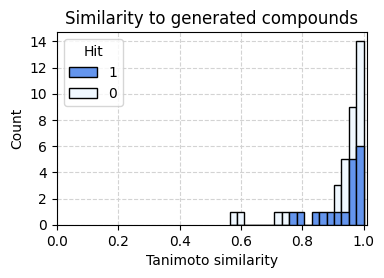

In [ ]:
import seaborn as sns
plt.figure(figsize=(4, 2.5))
sns.histplot(
    data=global_results,
    x="tanimotos",
    hue="Hit",
    binwidth=0.025,
    palette=["cornflowerblue", "aliceblue"],
    alpha=1,
    hue_order=[1, 0],
    zorder=2,
)
plt.xlabel("Tanimoto similarity")
plt.title("Similarity to generated compounds")
plt.xlim(0, 1.01)
plt.yticks(np.arange(0, 15, 2))
plt.grid(linestyle="--", color="lightgrey", zorder=-2)
plt.show()
plt.close()

## Compare to % inhibition

In [ ]:
results = pd.read_excel(
    "/aloy/home/grojas/tesis/cell_line_specific_NCEs/scripts/generative_models/09_2023_generation_for_paper/experimental_validation/20240502_Resultados.xlsx"
)
results.head()

,Plate No.,Plate Name,Plate Barcode,Location,Sample,Well Type,Raw Data Result,% inhibition,Conc,Cell Line
0,1,BXPC3_replica1_12839,NaN,A01,HIGH,High Control,6555500,18.853,NaN,BXPC3
1,2,BXPC3_replica2_12843,NaN,A01,HIGH,High Control,6854700,18.496,NaN,BXPC3
2,3,BXPC3_replica3_12847,NaN,A01,HIGH,High Control,6159900,27.641,NaN,BXPC3
3,4,CAPAN_replica1_12842,NaN,A01,HIGH,High Control,4816200,14.645,NaN,CAPAN
4,5,CAPAN_replica2_12846,NaN,A01,HIGH,High Control,5105000,12.588,NaN,CAPAN


In [ ]:
np.unique(results["Plate Name"])

array(['BXPC3_replica1_12839', 'BXPC3_replica2_12843',
       'BXPC3_replica3_12847', 'CAPAN_replica1_12842',
       'CAPAN_replica2_12846', 'CAPAN_replica3_12850',
       'CFPAC_replica1_12840', 'CFPAC_replica2_12844',
       'CFPAC_replica3_12848', 'HEK_replica1_12841', 'HEK_replica2_12845',
       'HEK_replica3_12849'], dtype=object)

In [ ]:
results["Plate Name"] = [
    s.split("_")[0] + "_" + s.split("_")[1] for s in results["Plate Name"].values
]
results.head(2)

,Plate No.,Plate Name,Plate Barcode,Location,Sample,Well Type,Raw Data Result,% inhibition,Conc,Cell Line
0,1,BXPC3_replica1,NaN,A01,HIGH,High Control,6555500,18.853,NaN,BXPC3
1,2,BXPC3_replica2,NaN,A01,HIGH,High Control,6854700,18.496,NaN,BXPC3


In [ ]:
np.unique(results.dropna(subset="Well Type")["Well Type"])

array(['DMSO', 'High Control', 'Low Control', 'Positive Control',
       'Sample'], dtype=object)

In [ ]:
r10uM = results[
    np.logical_and(results["Conc"] == "10 uM", results["Well Type"] == "Sample")
]

In [ ]:
r1uM = results[
    np.logical_and(results["Conc"] == "1 uM", results["Well Type"] == "Sample")
]

In [ ]:
r10uM.head()

,Plate No.,Plate Name,Plate Barcode,Location,Sample,Well Type,Raw Data Result,% inhibition,Conc,Cell Line
24,1,BXPC3_replica1,NaN,A03,4204_0050,Sample,7201800,10.724,10 uM,BXPC3
25,2,BXPC3_replica2,NaN,A03,4204_0050,Sample,7220600,14.077,10 uM,BXPC3
26,3,BXPC3_replica3,NaN,A03,4204_0050,Sample,7191300,15.331,10 uM,BXPC3
27,4,CAPAN_replica1,NaN,A03,4204_0050,Sample,4638800,17.828,10 uM,CAPAN
28,5,CAPAN_replica2,NaN,A03,4204_0050,Sample,4579200,21.714,10 uM,CAPAN


In [ ]:
r10uM = r10uM[["Sample", "% inhibition", "Plate Name"]]
# r10uM = r10uM.groupby(["Sample", "Cell Line"], as_index=False).mean()

In [ ]:
r10uM.shape

(1212, 3)

In [ ]:
# Pivot the DataFrame
r10uM = r10uM.pivot_table(index="Sample", columns="Plate Name", values="% inhibition")
print(r10uM.shape)
r10uM.head()

(101, 12)


Plate Name,BXPC3_replica1,BXPC3_replica2,BXPC3_replica3,CAPAN_replica1,CAPAN_replica2,CAPAN_replica3,CFPAC_replica1,CFPAC_replica2,CFPAC_replica3,HEK_replica1,HEK_replica2,HEK_replica3
Sample,,,,,,,,,,,,
0234_0037,-2.0312,4.8807,5.0978,7.9744,11.44200,11.5760,7.2874,9.1669,3.1971,8.8908,-3.2150,4.0320
0310_0156,39.6760,39.4230,41.6630,26.2320,22.00100,16.5620,39.1960,34.8630,31.6370,54.6500,51.0450,46.3940
1488_2470,-7.6512,-3.4707,-4.8612,2.3045,0.13859,-2.8747,-3.5085,-2.2630,-11.9720,-5.9501,-10.2890,-18.1570
2082_0205,-1.3490,3.2179,-2.9687,13.3610,2.63990,-7.4815,-8.1036,1.4447,-1.9615,5.5646,15.2070,2.9583
4204_0050,10.7240,14.0770,15.3310,17.8280,21.71400,22.6260,7.3437,14.9570,20.7620,5.6455,2.6359,14.6670


In [ ]:
r10uM[r10uM.index == "4204_0050"]

Plate Name,BXPC3_replica1,BXPC3_replica2,BXPC3_replica3,CAPAN_replica1,CAPAN_replica2,CAPAN_replica3,CFPAC_replica1,CFPAC_replica2,CFPAC_replica3,HEK_replica1,HEK_replica2,HEK_replica3
Sample,,,,,,,,,,,,
4204_0050,10.724,14.077,15.331,17.828,21.714,22.626,7.3437,14.957,20.762,5.6455,2.6359,14.667


In [ ]:
r10uM.columns

Index(['BXPC3_replica1', 'BXPC3_replica2', 'BXPC3_replica3', 'CAPAN_replica1',
       'CAPAN_replica2', 'CAPAN_replica3', 'CFPAC_replica1', 'CFPAC_replica2',
       'CFPAC_replica3', 'HEK_replica1', 'HEK_replica2', 'HEK_replica3'],
      dtype='object', name='Plate Name')

In [ ]:
r10uM.index

Index(['0234_0037', '0310_0156', '1488_2470', '2082_0205', '4204_0050',
       '4204_0078', '4456_3685', '4522_0018', '4896_4876', '5003_0099',
       ...
       'MCULE_8318145015', 'MCULE_8388595355', 'MCULE_8454725046',
       'MCULE_8811163919', 'MCULE_9301248301', 'Y021_4491', 'Z1576602625',
       'Z1883550099', 'Z3025619666', 'Z397858992'],
      dtype='object', name='Sample', length=101)

In [ ]:
r1uM = r1uM[["Sample", "% inhibition", "Plate Name"]]

In [ ]:
r1uM.shape

(1212, 3)

In [ ]:
# Pivot the DataFrame
r1uM = r1uM.pivot_table(index="Sample", columns="Plate Name", values="% inhibition")
print(r1uM.shape)
r1uM.head()

(101, 12)


Plate Name,BXPC3_replica1,BXPC3_replica2,BXPC3_replica3,CAPAN_replica1,CAPAN_replica2,CAPAN_replica3,CFPAC_replica1,CFPAC_replica2,CFPAC_replica3,HEK_replica1,HEK_replica2,HEK_replica3
Sample,,,,,,,,,,,,
0234_0037,-4.77710,1.39220,-7.79550,-1.19680,0.07334,5.4435,0.36255,6.8314,-1.5827,-2.712,5.2396,1.89280
0310_0156,-0.95513,2.93040,-7.29990,-2.81650,1.60130,-8.5741,0.48035,3.0799,-8.6046,25.107,12.7310,23.08600
1488_2470,-1.76510,-1.13680,-0.22501,9.39460,-5.92550,2.3842,-0.82524,-2.6478,-3.0013,-10.865,-12.5760,-18.50800
2082_0205,-10.62400,-0.36774,-0.89769,-0.51005,4.46990,-5.4549,-6.77540,6.8525,-13.3180,14.340,8.7752,0.48616
4204_0050,8.33940,18.00400,16.61900,11.06900,12.77200,9.1631,6.22800,8.5847,9.7842,18.051,8.3753,12.14800


In [ ]:
clls = ['CAPAN', 'BXPC3', 'CFPAC', 'HEK']
# Aggregate replicates
for cll in clls:
    replicates = r10uM.filter(like=cll)
    mean2closest = []
    for i in range(len(replicates)):
        aux = replicates.iloc[i, :]
        a = abs(aux[0] - aux[1])
        b = abs(aux[0] - aux[2])
        c = abs(aux[1] - aux[2])
        min_index = np.where([a, b, c] == min([a, b, c]))[0]
        if min_index == 0:
            mean2closest.append(np.mean([aux[0], aux[1]]))
        elif min_index == 1:
            mean2closest.append(np.mean([aux[0], aux[2]]))
        elif min_index == 2:
            mean2closest.append(np.mean([aux[1], aux[2]]))

    r10uM[cll + "_mean"] = replicates.mean(axis=1)
    r10uM[cll + "_mean2closest"] = mean2closest

/tmp/ipykernel_1918058/2683735076.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = abs(aux[0] - aux[1])
/tmp/ipykernel_1918058/2683735076.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b = abs(aux[0] - aux[2])
/tmp/ipykernel_1918058/2683735076.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c = abs(aux[1] - aux[2])
/tmp/ipykernel_1918058/2683735076.py:17: FutureWarning: Series.__getitem__ treating keys as positions 

In [ ]:
# Aggregate replicates
for cll in clls:
    replicates = r1uM.filter(like=cll)
    mean2closest = []
    for i in range(len(replicates)):
        aux = replicates.iloc[i, :]
        a = abs(aux[0] - aux[1])
        b = abs(aux[0] - aux[2])
        c = abs(aux[1] - aux[2])
        min_index = np.where([a, b, c] == min([a, b, c]))[0]
        if min_index == 0:
            mean2closest.append(np.mean([aux[0], aux[1]]))
        elif min_index == 1:
            mean2closest.append(np.mean([aux[0], aux[2]]))
        elif min_index == 2:
            mean2closest.append(np.mean([aux[1], aux[2]]))

    r1uM[cll + "_mean"] = replicates.mean(axis=1)
    r1uM[cll + "_mean2closest"] = mean2closest

/tmp/ipykernel_1918058/1274348408.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = abs(aux[0] - aux[1])
/tmp/ipykernel_1918058/1274348408.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b = abs(aux[0] - aux[2])
/tmp/ipykernel_1918058/1274348408.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c = abs(aux[1] - aux[2])
/tmp/ipykernel_1918058/1274348408.py:12: FutureWarning: Series.__getitem__ treating keys as positions i

In [ ]:
r1uM

Plate Name,BXPC3_replica1,BXPC3_replica2,BXPC3_replica3,CAPAN_replica1,CAPAN_replica2,CAPAN_replica3,CFPAC_replica1,CFPAC_replica2,CFPAC_replica3,HEK_replica1,HEK_replica2,HEK_replica3,CAPAN_mean,CAPAN_mean2closest,BXPC3_mean,BXPC3_mean2closest,CFPAC_mean,CFPAC_mean2closest,HEK_mean,HEK_mean2closest
Sample,,,,,,,,,,,,,,,,,,,,
0234_0037,-4.77710,1.39220,-7.79550,-1.19680,0.07334,5.44350,0.36255,6.8314,-1.5827,-2.7120,5.2396,1.89280,1.440013,-0.561730,-3.726800,-6.286300,1.870417,-0.610075,1.473467,3.56620
0310_0156,-0.95513,2.93040,-7.29990,-2.81650,1.60130,-8.57410,0.48035,3.0799,-8.6046,25.1070,12.7310,23.08600,-3.263100,-0.607600,-1.774877,0.987635,-1.681450,1.780125,20.308000,24.09650
1488_2470,-1.76510,-1.13680,-0.22501,9.39460,-5.92550,2.38420,-0.82524,-2.6478,-3.0013,-10.8650,-12.5760,-18.50800,1.951100,5.889400,-1.042303,-1.450950,-2.158113,-2.824550,-13.983000,-11.72050
2082_0205,-10.62400,-0.36774,-0.89769,-0.51005,4.46990,-5.45490,-6.77540,6.8525,-13.3180,14.3400,8.7752,0.48616,-0.498350,-2.982475,-3.963143,-0.632715,-4.413633,-10.046700,7.867120,11.55760
4204_0050,8.33940,18.00400,16.61900,11.06900,12.77200,9.16310,6.22800,8.5847,9.7842,18.0510,8.3753,12.14800,11.001367,11.920500,14.320800,17.311500,8.198967,9.184450,12.858100,10.26165
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Y021_4491,-6.21490,0.98350,-8.51690,-8.08460,-11.36600,-8.05640,-5.05420,-1.3026,-6.8810,-5.3893,-6.5619,-14.34300,-9.169000,-8.070500,-4.582767,-7.365900,-4.412600,-5.967600,-8.764733,-5.97560
Z1576602625,2.29630,4.57630,-3.16780,3.97080,7.79530,9.85110,10.22700,16.7710,2.0513,-7.8912,2.9668,1.24470,7.205733,8.823200,1.234933,3.436300,9.683100,13.499000,-1.226567,2.10575
Z1883550099,-6.31100,2.18160,-4.35610,-0.25960,2.13800,-0.65093,-10.79700,1.9351,-2.5194,-16.5980,5.6724,-14.13300,0.409157,-0.455265,-2.828500,-5.333550,-3.793767,-0.292150,-8.352867,-15.36550


In [ ]:
r10uM["cpd"] = [s.replace("_", "-") for s in r10uM.index]
r1uM["cpd"] = [s.replace("_", "-") for s in r1uM.index]

In [ ]:
np.isin(global_results['cpd'], r10uM['cpd']).sum()

np.int64(53)

In [ ]:
global_results.columns

Index(['cpd', 'Hit', 'tanimotos', 'exercise'], dtype='object')

In [ ]:
sum(global_results['tanimotos']==1)

15

In [ ]:
global_results[global_results['tanimotos']<1].cpd.nunique()

34

In [ ]:
global_results[global_results['tanimotos']==1].cpd.nunique()

15

In [ ]:
global_results.shape

(53, 4)

In [ ]:
global_results.cpd.nunique()

45

In [ ]:
cpds_tested['Query Mcule ID'].nunique()

45

In [ ]:
cpds_tested['Query Mcule ID'][~cpds_tested['Query Mcule ID'].isin(global_results['cpd'])]

Series([], Name: Query Mcule ID, dtype: object)

In [ ]:
r10uM['cpd'].nunique()

101

In [ ]:
sum(global_results['tanimotos']==1)

15

In [ ]:
global_results['exercise'].value_counts()

exercise
BXPC3_vs_HEK      22
BXPC3_vs_CAPAN    16
HEK_vs_CFPAC      11
CAPAN_vs_HEK       1
CAPAN_vs_CFPAC     1
HEK_vs_BXPC3       1
HEK_vs_CAPAN       1
Name: count, dtype: int64

In [ ]:
thresholds = {
    "CAPAN": 30.9,
    "SW1990": 36.89,
    "BXPC3": 21.95,
    "HPAFII": 20.89,
    "CFPAC": 35.05,
    "PANC": 27.26,
    "ASPC1": 30.52,
    "HEK": 48.15,
}

In [ ]:
combinations = [c[0]+'_vs_'+c[1] for c in combinations]

In [ ]:
from scipy.stats import pearsonr

all_rows = []

for ex in combinations:
    cl1, cl2 = ex.split('_vs_')

    aux = global_results[
        (global_results['exercise'] == ex) 
        # &(global_results['worked'] == 1)
    ]

    # --- 10 µM ---
    merged_10 = pd.merge(aux, r10uM, on="cpd", how="inner")

    merged_10['deltas_affected'] = (
        merged_10[f"{cl1}_mean2closest"] - thresholds[cl1]
    )
    merged_10['deltas_unaffected'] = (
        merged_10[f"{cl2}_mean2closest"] - thresholds[cl2]
    )

    merged_10['exercise'] = ex
    merged_10['concentration'] = '10uM'

    all_rows.append(
        merged_10[
            ['cpd', 'exercise', 'concentration',
             'tanimotos', 'deltas_affected', 'deltas_unaffected']
        ]
    )

    # --- 1 µM ---
    merged_1 = pd.merge(aux, r1uM, on="cpd", how="inner")

    merged_1['deltas_affected'] = (
        merged_1[f"{cl1}_mean2closest"] - thresholds[cl1]
    )
    merged_1['deltas_unaffected'] = (
        merged_1[f"{cl2}_mean2closest"] - thresholds[cl2]
    )

    merged_1['exercise'] = ex
    merged_1['concentration'] = '1uM'

    all_rows.append(
        merged_1[
            ['cpd', 'exercise', 'concentration',
             'tanimotos', 'deltas_affected', 'deltas_unaffected']
        ]
    )

# 🔹 Final dataframe with ALL compounds
deltas_df = pd.concat(all_rows, ignore_index=True)


In [ ]:
plot_df['delta_combined'] = (
    plot_df['deltas_affected'] - plot_df['deltas_unaffected']
)

if len(plot_df) > 1:
    r, p = pearsonr(plot_df['tanimotos'], plot_df['delta_combined'])
    print(f"Global Pearson r = {r:.2f}, p = {p:.2g}")


Global Pearson r = 0.27, p = 0.049


In [ ]:
all_rows = []

for ex in combinations:
    cl1, cl2 = ex.split('_vs_')

    aux = global_results[
        (global_results['exercise'] == ex) 
        # & (global_results['worked'] == 1)
    ]

    # ---------- 10 µM ----------
    m10 = pd.merge(aux, r10uM, on="cpd", how="inner")

    m10['deltas_affected'] = m10[f"{cl1}_mean2closest"] - thresholds[cl1]
    m10['deltas_unaffected'] = m10[f"{cl2}_mean2closest"] - thresholds[cl2]

    m10['exercise'] = ex
    m10['concentration'] = '10uM'

    all_rows.append(
        m10[['cpd','exercise','concentration',
             'tanimotos','deltas_affected','deltas_unaffected']]
    )

    # ---------- 1 µM ----------
    m1 = pd.merge(aux, r1uM, on="cpd", how="inner")

    m1['deltas_affected'] = m1[f"{cl1}_mean2closest"] - thresholds[cl1]
    m1['deltas_unaffected'] = m1[f"{cl2}_mean2closest"] - thresholds[cl2]

    m1['exercise'] = ex
    m1['concentration'] = '1uM'

    all_rows.append(
        m1[['cpd','exercise','concentration',
            'tanimotos','deltas_affected','deltas_unaffected']]
    )

deltas_df = pd.concat(all_rows, ignore_index=True)


In [ ]:
df10

NameError: name 'df10' is not defined

In [ ]:
deltas_df.head(2)

,cpd,exercise,concentration,tanimotos,deltas_affected,deltas_unaffected
0,Z3025619666,BXPC3_vs_CAPAN,10uM,0.972875,43.3375,-4.3430
1,MCULE-1153524502,BXPC3_vs_CAPAN,10uM,0.961468,34.5790,4.4795


In [ ]:
deltas_df['worked'] = np.logical_and(deltas_df['deltas_affected']>=0,deltas_df['deltas_unaffected']<=0)*1
deltas_df.worked.sum()

np.int64(21)

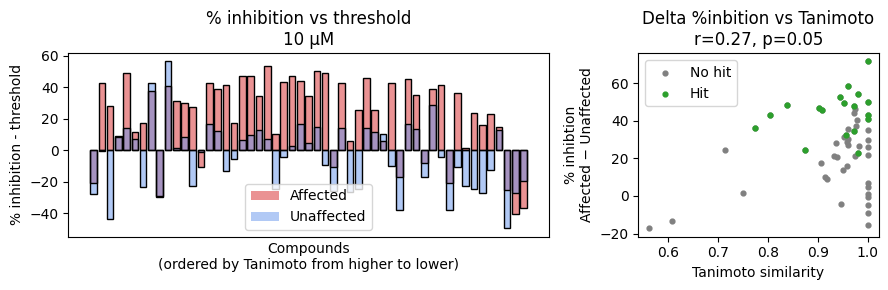

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3), gridspec_kw={'width_ratios': [2, 1]})

# ---------- 10 µM ----------
df10 = deltas_df[deltas_df['concentration'] == '10uM'].drop_duplicates()
df10 = df10.sort_values('tanimotos', ascending=False)

x10 = np.arange(len(df10))

ax1.bar(x10, df10['deltas_affected'],
        color='tab:red', alpha=0.5, label='Affected', zorder=2)
ax1.bar(x10, df10['deltas_unaffected'],
        color='cornflowerblue', alpha=0.5, label='Unaffected', zorder=2)

# outlines
ax1.bar(x10, df10['deltas_affected'], fill=False, edgecolor='black', zorder=3)
ax1.bar(x10, df10['deltas_unaffected'], fill=False, edgecolor='black', zorder=3)

ax1.set_title('% inhibition vs threshold\n10 µM')
ax1.set_xticks([])
ax1.legend()

# ---------- 1 µM ----------
# df1 = deltas_df[deltas_df['concentration'] == '1uM']
# df1 = df1.sort_values('tanimotos', ascending=False)

# x1 = np.arange(len(df1))

# ax2.bar(x1, df1['deltas_affected'],
#         color='tab:red', alpha=0.5, zorder=2)
# ax2.bar(x1, df1['deltas_unaffected'],
#         color='cornflowerblue', alpha=0.5, zorder=2)

# ax2.bar(x1, df1['deltas_affected'], fill=False, edgecolor='black', zorder=3)
# ax2.bar(x1, df1['deltas_unaffected'], fill=False, edgecolor='black', zorder=3)

# ax2.set_title('% inhibition vs threshold\n1 µM')
# ax2.set_xticks([])

# ---------- Combined delta vs tanimoto ----------
df10['delta_combined'] = (
    df10['deltas_affected'] - df10['deltas_unaffected']
)

ax2.scatter(
    df10['tanimotos'],
    df10['delta_combined'],
    s=12,
    # alpha=0.7,
    color='grey',
    # edgecolor='black',
    label='No hit'
)

aux = df10[df10['worked']==1]
ax2.scatter(
    aux['tanimotos'],
    aux['delta_combined'],
    s=12,
    # alpha=0.7,
    color='tab:green',
    # edgecolor='black',
    label='Hit'
)

if len(df10) > 1:
    r, p = pearsonr(df10['tanimotos'], df10['delta_combined'])
    ax2.set_title(f'Delta %inbition vs Tanimoto\nr={r:.2f}, p={p:.2f}')
else:
    ax2.set_title('Delta %%inbition vs Tanimoto')

ax2.set_xlabel('Tanimoto similarity')
ax2.set_ylabel(f'% inhibtion\nAffected − Unaffected')
ax2.legend()

ax1.set_ylabel(f'% inhibition - threshold')
ax1.set_xlabel(f'Compounds\n(ordered by Tanimoto from higher to lower)')

plt.tight_layout()
plt.savefig('activity_vs_tanimoto_to_generated_compounds.svg', dpi=300)
plt.show()
